In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dku-data-science/rtu_data_full.csv
/kaggle/input/dku-data-science/submissionfile_sample.csv
/kaggle/input/dku-data-science/train.csv
/kaggle/input/dku-data-science/test.csv


In [2]:
df = pd.read_csv(dirname + '/train.csv')
df.head()

,module(equipment),timestamp,localtime,operation,voltageR,voltageS,voltageT,voltageRS,voltageST,voltageTR,currentR,currentS,currentT,activePower,powerFactorR,powerFactorS,powerFactorT,reactivePowerLagging,accumActiveEnergy,datetime
0,1(PM-3),1733040000000,20241201000000,1,214.38,214.45,219.10,371.37,375.45,375.39,15.16,15.53,20.65,2961.61,87.31,99.71,89.45,785.37,1955004,2024-12-01 00:00:00
1,1(PM-3),1733040005000,20241201000005,1,214.05,211.74,218.68,368.73,372.74,374.74,25.70,7.07,19.75,3017.48,87.54,87.67,94.17,376.57,1955008,2024-12-01 00:00:05
2,1(PM-3),1733040010000,20241201000010,1,215.79,214.92,211.10,373.00,368.94,369.69,13.64,14.87,13.70,2408.01,85.46,99.00,94.45,296.08,1955011,2024-12-01 00:00:10
3,1(PM-3),1733040015000,20241201000015,1,210.39,214.92,215.57,368.32,372.80,368.89,25.76,26.35,5.80,3289.33,85.24,99.53,95.61,488.48,1955016,2024-12-01 00:00:15
4,1(PM-3),1733040020000,20241201000020,1,216.71,216.37,215.65,375.05,374.13,374.43,8.65,29.49,15.09,3069.31,92.81,91.26,91.82,604.70,1955020,2024-12-01 00:00:20


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27181440 entries, 0 to 27181439
Data columns (total 20 columns):
 #   Column                Dtype  
---  ------                -----  
 0   module(equipment)     object 
 1   timestamp             int64  
 2   localtime             int64  
 3   operation             int64  
 4   voltageR              float64
 5   voltageS              float64
 6   voltageT              float64
 7   voltageRS             float64
 8   voltageST             float64
 9   voltageTR             float64
 10  currentR              float64
 11  currentS              float64
 12  currentT              float64
 13  activePower           float64
 14  powerFactorR          float64
 15  powerFactorS          float64
 16  powerFactorT          float64
 17  reactivePowerLagging  float64
 18  accumActiveEnergy     int64  
 19  datetime              object 
dtypes: float64(14), int64(4), object(2)
memory usage: 4.1+ GB


- ActivePower : 순간의 유효 전력
- AccumActiveEnergy: 누적 유효 전력

In [4]:
df.describe()

,timestamp,localtime,operation,voltageR,voltageS,voltageT,voltageRS,voltageST,voltageTR,currentR,currentS,currentT,activePower,powerFactorR,powerFactorS,powerFactorT,reactivePowerLagging,accumActiveEnergy
count,2.718144e+07,2.718144e+07,27181440.0,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07
mean,1.738267e+12,2.024791e+13,1.0,2.149938e+02,2.149946e+02,2.149946e+02,3.723699e+02,3.723706e+02,3.723699e+02,1.749953e+01,1.749883e+01,1.750261e+01,3.009975e+03,9.246984e+01,9.247057e+01,9.246874e+01,6.019512e+02,7.055947e+06
std,3.016970e+09,3.929252e+09,0.0,2.901866e+00,2.902405e+00,2.902151e+00,3.572511e+00,3.572509e+00,3.572434e+00,7.217245e+00,7.217796e+00,7.216499e+00,7.171598e+02,4.405668e+00,4.405326e+00,4.405634e+00,2.290593e+02,2.787661e+06
min,1.733040e+12,2.024120e+13,1.0,1.901000e+02,1.901800e+02,1.901800e+02,3.310000e+02,3.299500e+02,3.305600e+02,5.000000e+00,5.000000e+00,5.000000e+00,8.644400e+02,6.000000e+01,6.000000e+01,6.000000e+01,9.010000e+01,1.129004e+06
25%,1.735654e+12,2.024123e+13,1.0,2.125000e+02,2.125000e+02,2.125000e+02,3.698400e+02,3.698400e+02,3.698400e+02,1.125000e+01,1.125000e+01,1.125000e+01,2.503800e+03,8.873000e+01,8.873000e+01,8.873000e+01,4.231600e+02,4.870391e+06
50%,1.738267e+12,2.025013e+13,1.0,2.150000e+02,2.150000e+02,2.150000e+02,3.723800e+02,3.723800e+02,3.723800e+02,1.750000e+01,1.750000e+01,1.750000e+01,3.009950e+03,9.249000e+01,9.249000e+01,9.249000e+01,5.739800e+02,7.055739e+06
75%,1.740881e+12,2.025030e+13,1.0,2.175000e+02,2.175000e+02,2.175000e+02,3.749200e+02,3.749200e+02,3.749200e+02,2.375000e+01,2.375000e+01,2.375000e+01,3.515940e+03,9.625000e+01,9.625000e+01,9.624000e+01,7.553900e+02,9.241356e+06
max,1.743491e+12,2.025033e+13,1.0,2.200000e+02,2.200000e+02,2.200000e+02,3.810400e+02,3.810400e+02,3.810400e+02,3.000000e+01,3.000000e+01,3.000000e+01,5.220930e+03,1.000000e+02,1.000000e+02,1.000000e+02,1.550630e+03,1.334350e+07


- Operation의 Min, Max가 1로 동일하다. 모두 가동 중일때 추출된 데이터다.
- Drop Column [Operation]

In [5]:
# 결측치 확인
df.isna().sum()

module(equipment)       0
timestamp               0
localtime               0
operation               0
voltageR                0
voltageS                0
voltageT                0
voltageRS               0
voltageST               0
voltageTR               0
currentR                0
currentS                0
currentT                0
activePower             0
powerFactorR            0
powerFactorS            0
powerFactorT            0
reactivePowerLagging    0
accumActiveEnergy       0
datetime                0
dtype: int64

In [3]:
df = df.rename(columns={'module(equipment)': 'module'})
df['module'] = df['module'].str.split('(').str[0].str.strip()
df['datetime'] = pd.to_datetime(df['datetime'])

In [7]:
df.head()

,module,timestamp,localtime,operation,voltageR,voltageS,voltageT,voltageRS,voltageST,voltageTR,currentR,currentS,currentT,activePower,powerFactorR,powerFactorS,powerFactorT,reactivePowerLagging,accumActiveEnergy,datetime
0,1,1733040000000,20241201000000,1,214.38,214.45,219.10,371.37,375.45,375.39,15.16,15.53,20.65,2961.61,87.31,99.71,89.45,785.37,1955004,2024-12-01 00:00:00
1,1,1733040005000,20241201000005,1,214.05,211.74,218.68,368.73,372.74,374.74,25.70,7.07,19.75,3017.48,87.54,87.67,94.17,376.57,1955008,2024-12-01 00:00:05
2,1,1733040010000,20241201000010,1,215.79,214.92,211.10,373.00,368.94,369.69,13.64,14.87,13.70,2408.01,85.46,99.00,94.45,296.08,1955011,2024-12-01 00:00:10
3,1,1733040015000,20241201000015,1,210.39,214.92,215.57,368.32,372.80,368.89,25.76,26.35,5.80,3289.33,85.24,99.53,95.61,488.48,1955016,2024-12-01 00:00:15
4,1,1733040020000,20241201000020,1,216.71,216.37,215.65,375.05,374.13,374.43,8.65,29.49,15.09,3069.31,92.81,91.26,91.82,604.70,1955020,2024-12-01 00:00:20


In [4]:
df.set_index(['module', 'datetime'], inplace=True)
df.head()

timestamp       localtime  operation  \
module datetime                                                        
1      2024-12-01 00:00:00  1733040000000  20241201000000          1   
       2024-12-01 00:00:05  1733040005000  20241201000005          1   
       2024-12-01 00:00:10  1733040010000  20241201000010          1   
       2024-12-01 00:00:15  1733040015000  20241201000015          1   
       2024-12-01 00:00:20  1733040020000  20241201000020          1   

                            voltageR  voltageS  voltageT  voltageRS  \
module datetime                                                       
1      2024-12-01 00:00:00    214.38    214.45    219.10     371.37   
       2024-12-01 00:00:05    214.05    211.74    218.68     368.73   
       2024-12-01 00:00:10    215.79    214.92    211.10     373.00   
       2024-12-01 00:00:15    210.39    214.92    215.57     368.32   
       2024-12-01 00:00:20    216.71    216.37    215.65     375.05   

                            voltageST  voltageTR  currentR  currentS  \
module datetime                                                        
1      2024-12-01 00:00:00     375.45     375.39     15.16     15.53   
       2024-12-01 00:00:05     372.74     374.74     25.70      7.07   
       2024-12-01 00:00:10     368.94     369.69     13.64     14.87   
       2024-12-01 00:00:15     372.80     368.89     25.76     26.35   
       2024-12-01 00:00:20     374.13     374.43      8.65     29.49   

                            currentT  activePower  powerFactorR  powerFactorS  \
module datetime                                                                 
1      2024-12-01 00:00:00     20.65      2961.61         87.31         99.71   
       2024-12-01 00:00:05     19.75      3017.48         87.54         87.67   
       2024-12-01 00:00:10     13.70      2408.01         85.46         99.00   
       2024-12-01 00:00:15      5.80      3289.33         85.24         99.53   
       2024-12-01 00:00:20     15.09      3069.31         92.81         91.26   

                            powerFactorT  reactivePowerLagging  \
module datetime                                                  
1      2024-12-01 00:00:00         89.45                785.37   
       2024-12-01 00:00:05         94.17                376.57   
       2024-12-01 00:00:10         94.45                296.08   
       2024-12-01 00:00:15         95.61                488.48   
       2024-12-01 00:00:20         91.82                604.70   

                            accumActiveEnergy  
module datetime                                
1      2024-12-01 00:00:00            1955004  
       2024-12-01 00:00:05            1955008  
       2024-12-01 00:00:10            1955011  
       2024-12-01 00:00:15            1955016  
       2024-12-01 00:00:20            1955020

In [5]:
df.drop(columns=['timestamp', 'operation', 'localtime'], inplace=True)

In [6]:
import gc

gc.collect()


20

In [7]:
# Feature Engineering
import matplotlib.pyplot as plt
import seaborn as sns

df_corr=df.corr(numeric_only=True)
active_corr = df_corr['activePower'].sort_values(ascending=False)
print(active_corr.iloc[1:])  # 첫 번째 인덱스(자기 자신)를 제외한 상관관게 내림차순 정렬
top_10_features = active_corr.iloc[1:11].index
print(top_10_features)

reactivePowerLagging    0.625847
currentR                0.577081
currentS                0.577072
currentT                0.576859
voltageRS               0.027070
voltageTR               0.026997
voltageST               0.026957
voltageR                0.019269
voltageS                0.019209
voltageT                0.019107
powerFactorT            0.000271
accumActiveEnergy       0.000224
powerFactorR            0.000199
powerFactorS           -0.000133
Name: activePower, dtype: float64
Index(['reactivePowerLagging', 'currentR', 'currentS', 'currentT', 'voltageRS',
       'voltageTR', 'voltageST', 'voltageR', 'voltageS', 'voltageT'],
      dtype='object')


In [8]:
modules = df.reset_index().module.unique()
modules

array(['1', '11', '12', '13', '14', '15', '16', '17', '18', '2', '3', '4',
       '5'], dtype=object)

In [13]:
df.head()

voltageR  voltageS  voltageT  voltageRS  \
module datetime                                                       
1      2024-12-01 00:00:00    214.38    214.45    219.10     371.37   
       2024-12-01 00:00:05    214.05    211.74    218.68     368.73   
       2024-12-01 00:00:10    215.79    214.92    211.10     373.00   
       2024-12-01 00:00:15    210.39    214.92    215.57     368.32   
       2024-12-01 00:00:20    216.71    216.37    215.65     375.05   

                            voltageST  voltageTR  currentR  currentS  \
module datetime                                                        
1      2024-12-01 00:00:00     375.45     375.39     15.16     15.53   
       2024-12-01 00:00:05     372.74     374.74     25.70      7.07   
       2024-12-01 00:00:10     368.94     369.69     13.64     14.87   
       2024-12-01 00:00:15     372.80     368.89     25.76     26.35   
       2024-12-01 00:00:20     374.13     374.43      8.65     29.49   

                            currentT  activePower  powerFactorR  powerFactorS  \
module datetime                                                                 
1      2024-12-01 00:00:00     20.65      2961.61         87.31         99.71   
       2024-12-01 00:00:05     19.75      3017.48         87.54         87.67   
       2024-12-01 00:00:10     13.70      2408.01         85.46         99.00   
       2024-12-01 00:00:15      5.80      3289.33         85.24         99.53   
       2024-12-01 00:00:20     15.09      3069.31         92.81         91.26   

                            powerFactorT  reactivePowerLagging  \
module datetime                                                  
1      2024-12-01 00:00:00         89.45                785.37   
       2024-12-01 00:00:05         94.17                376.57   
       2024-12-01 00:00:10         94.45                296.08   
       2024-12-01 00:00:15         95.61                488.48   
       2024-12-01 00:00:20         91.82                604.70   

                            accumActiveEnergy  
module datetime                                
1      2024-12-01 00:00:00            1955004  
       2024-12-01 00:00:05            1955008  
       2024-12-01 00:00:10            1955011  
       2024-12-01 00:00:15            1955016  
       2024-12-01 00:00:20            1955020

In [14]:
# try:
#     module_data = {m: df[df['module'] == m].copy() for m in modules}
# except e:
#     print(e)

In [9]:
corr_feature = ['activePower'] + list(top_10_features)

In [16]:
# box plot
def plot_boxplots(df, title='boxplot'):
    num_columns = len(df.columns)
    fig, axes = plt.subplots(nrows=1, ncols = num_columns, figsize=(10, 5))
    fig.suptitle(title, fontsize=16)

    axes = axes.flatten()  # 서브플롯을 1차원 배열로 변환

    for i, column in enumerate(df.columns):
        sns.boxplot(y=df[column], ax=axes[i])
        axes[i].set_title(column)
        axes[i].set_ylabel('')

    # 빈 서브플롯 숨기기
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()  # 제목 공간 확보
    plt.show()

1


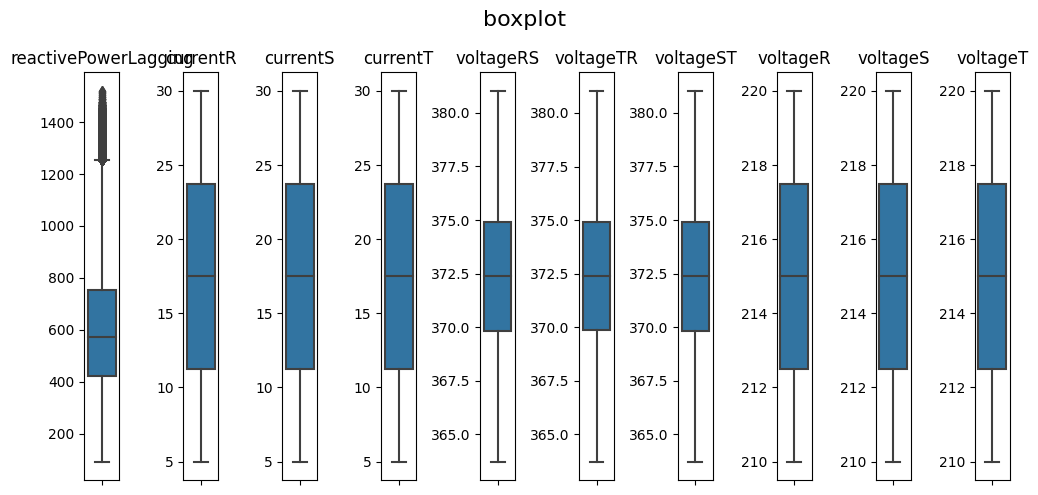

11


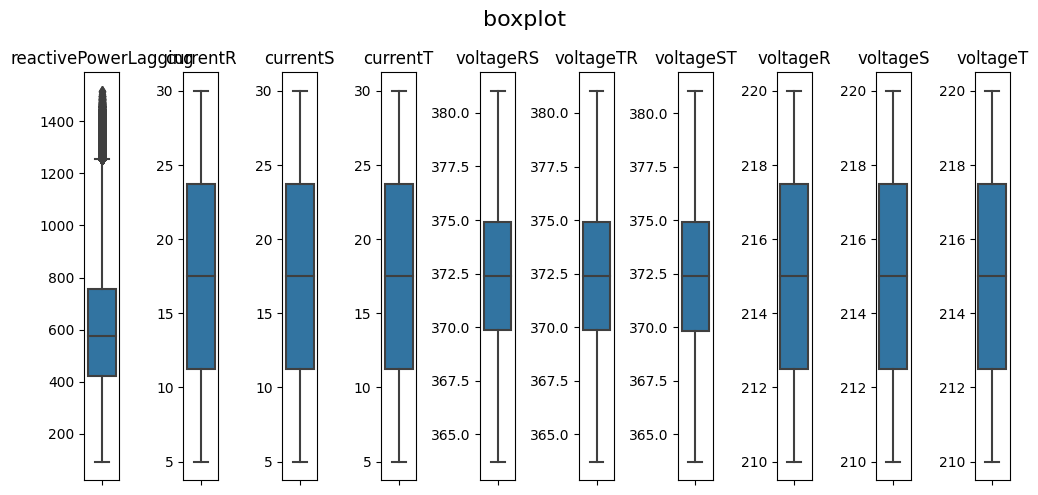

12


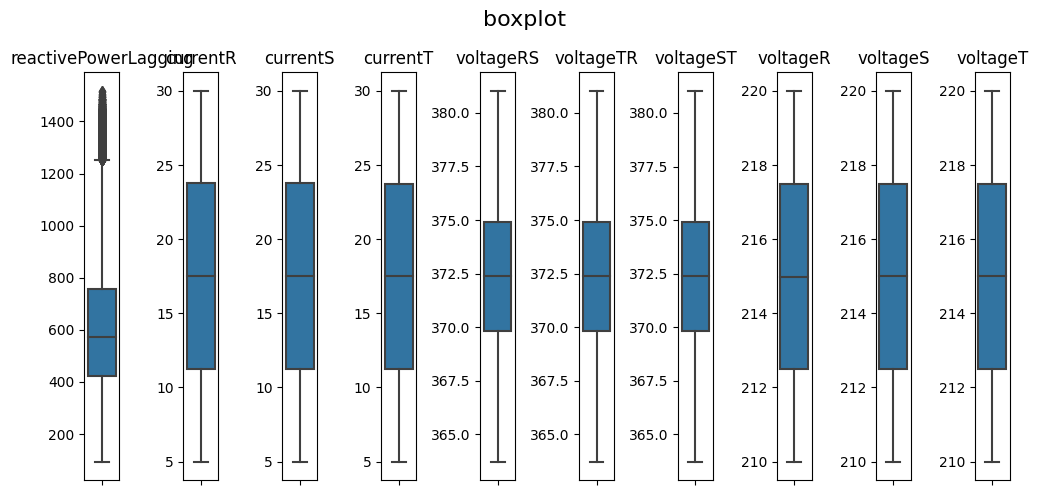

13


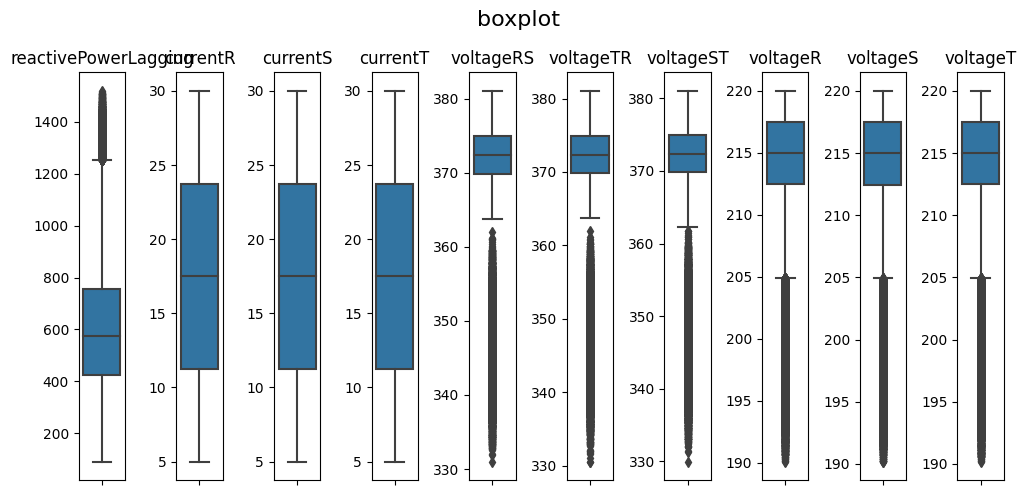

14


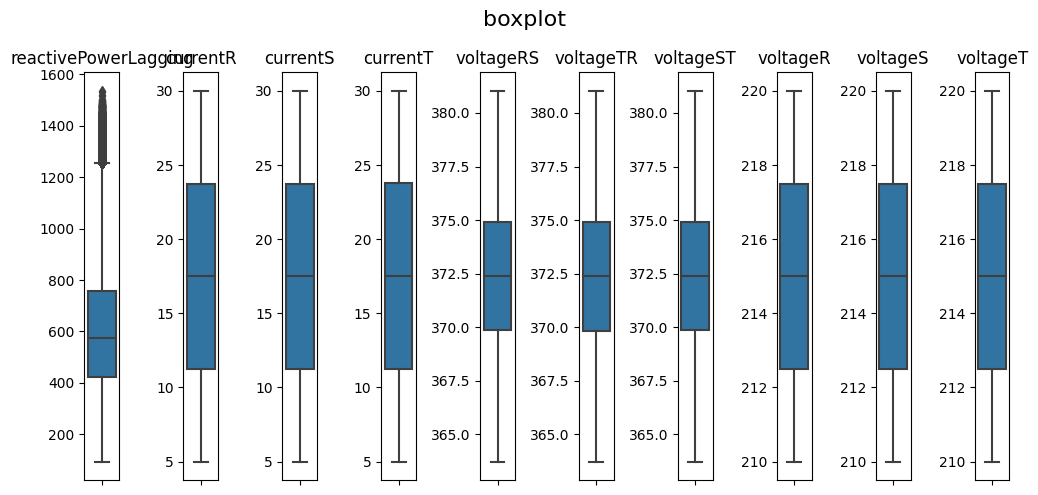

15


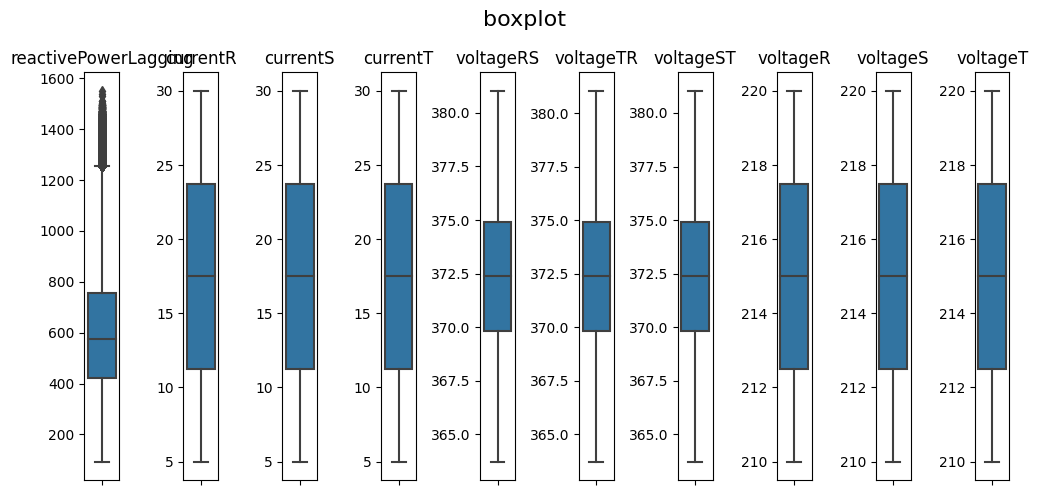

16


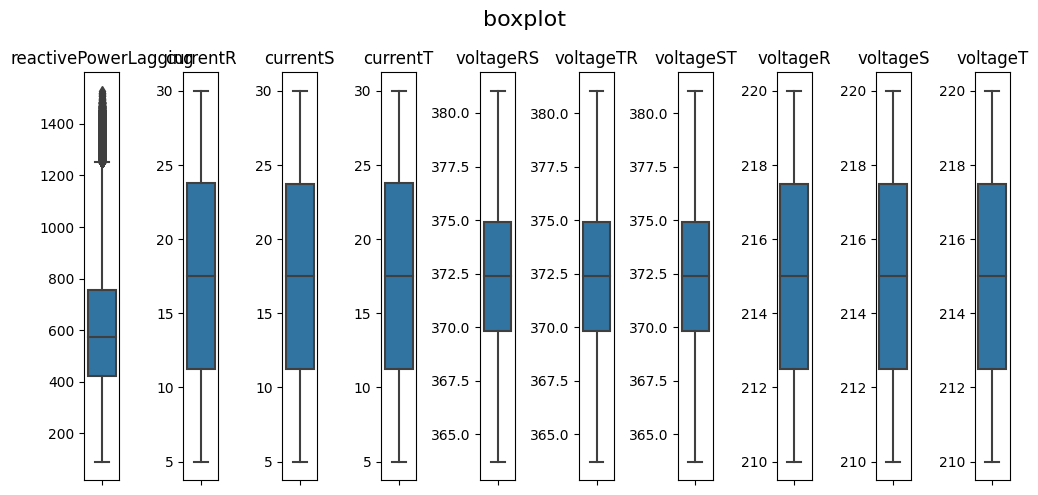

17


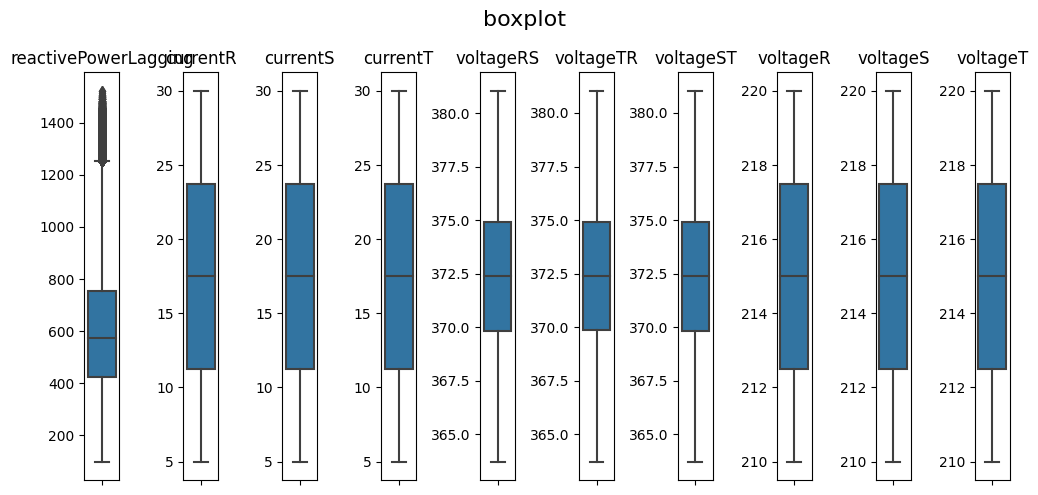

18


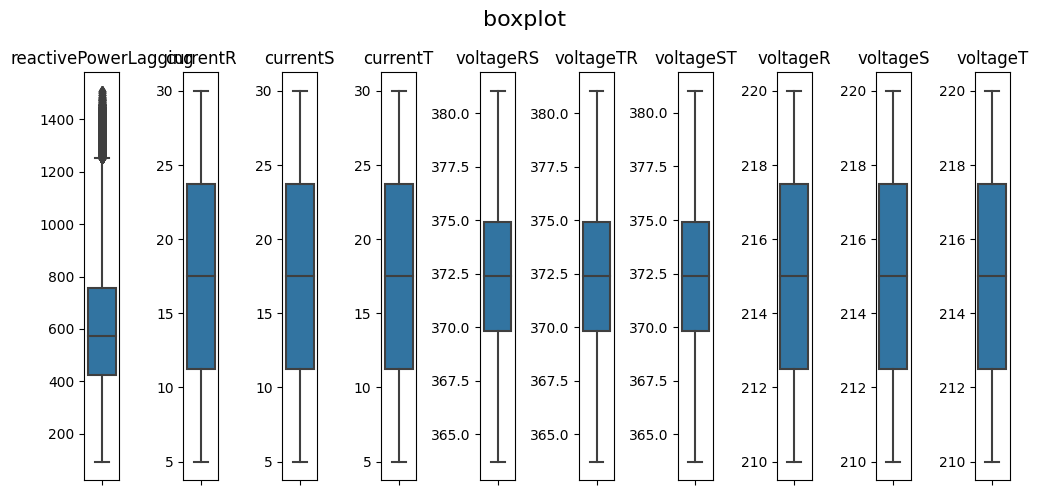

2


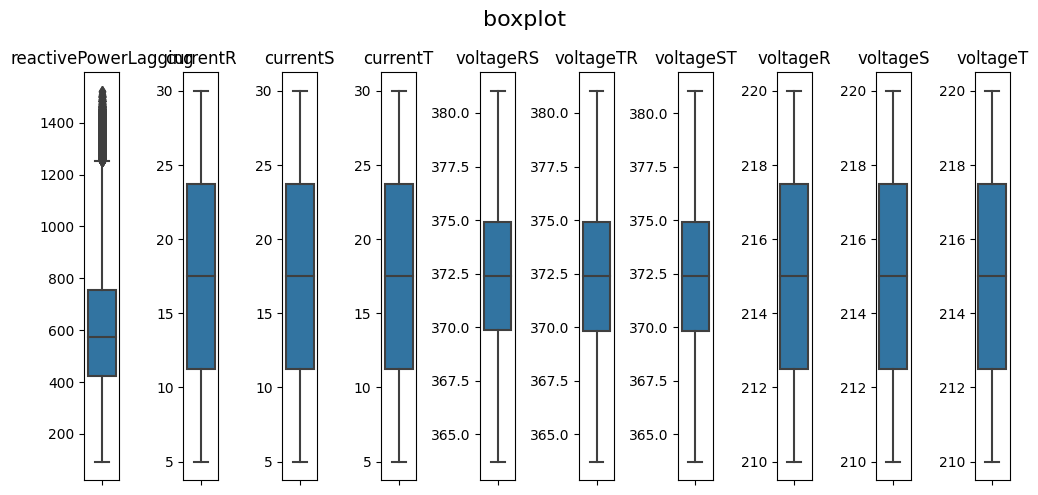

3


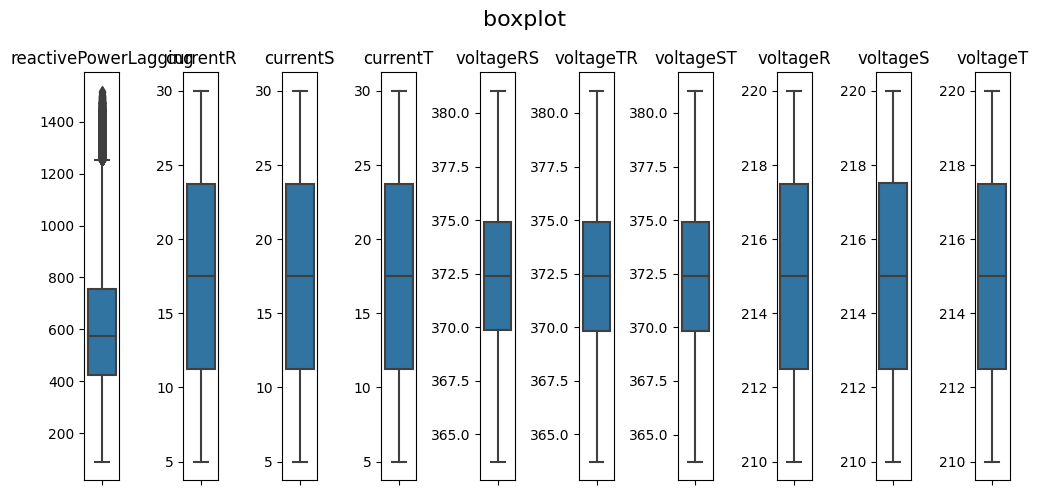

4


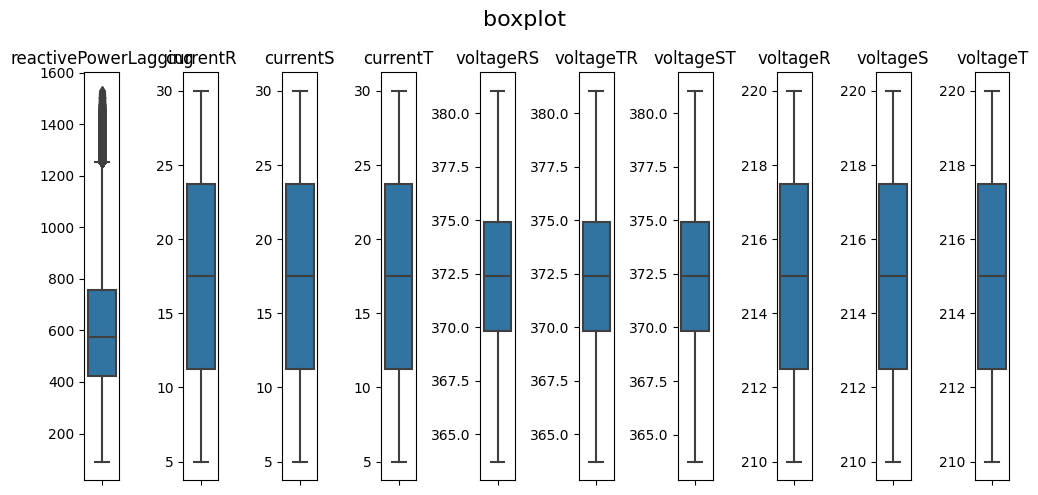

5


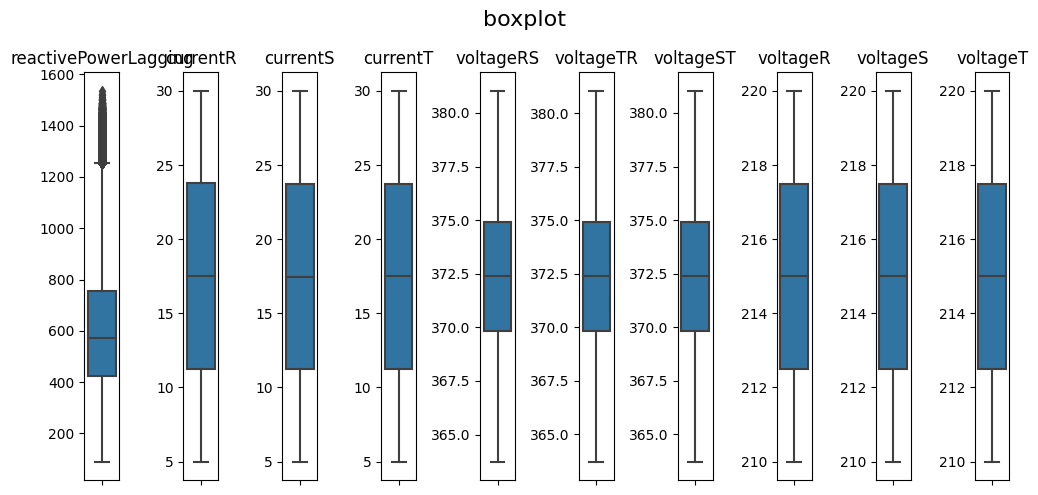

In [17]:
for mod, mod_df in df.groupby(level=0):
    print(mod)
    plot_boxplots(mod_df[top_10_features])

In [10]:
def replace_outliers_multiindex(df, features):
    for mod, mod_df in df.groupby(level=0):
        print(mod)
        for col in features:
            series = mod_df[col]

            # IQR 기반 이상치 마스킹
            Q1 = series.quantile(0.25)
            Q3 = series.quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR

            # 이상치를 NaN으로 대체 + 보간
            series = series.mask((series < lower) | (series > upper))
            series = series.interpolate(method='linear', limit_direction='both')
            series = series.fillna(method='ffill')

            # mod_df에 반영
            mod_df[col] = series

        # 원본 df에 반영 (RAM 절약 위해 loc 대입)
        df.loc[mod] = mod_df

    return df

In [11]:
df = replace_outliers_multiindex(df, corr_feature)

1


/tmp/ipykernel_35/948865376.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = series.fillna(method='ffill')
/tmp/ipykernel_35/948865376.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = series.fillna(method='ffill')
/tmp/ipykernel_35/948865376.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = series.fillna(method='ffill')
/tmp/ipykernel_35/948865376.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = series.fillna(method='ffill')
/tmp/ipykernel_35/948865376.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() inste

11


/tmp/ipykernel_35/948865376.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = series.fillna(method='ffill')
/tmp/ipykernel_35/948865376.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = series.fillna(method='ffill')
/tmp/ipykernel_35/948865376.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = series.fillna(method='ffill')
/tmp/ipykernel_35/948865376.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = series.fillna(method='ffill')
/tmp/ipykernel_35/948865376.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() inste

12


...

/tmp/ipykernel_35/948865376.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = series.fillna(method='ffill')
/tmp/ipykernel_35/948865376.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = series.fillna(method='ffill')
/tmp/ipykernel_35/948865376.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = series.fillna(method='ffill')
/tmp/ipykernel_35/948865376.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = series.fillna(method='ffill')
/tmp/ipykernel_35/948865376.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() inste

4


/tmp/ipykernel_35/948865376.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = series.fillna(method='ffill')
/tmp/ipykernel_35/948865376.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = series.fillna(method='ffill')
/tmp/ipykernel_35/948865376.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = series.fillna(method='ffill')
/tmp/ipykernel_35/948865376.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = series.fillna(method='ffill')
/tmp/ipykernel_35/948865376.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() inste

5


/tmp/ipykernel_35/948865376.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = series.fillna(method='ffill')
/tmp/ipykernel_35/948865376.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = series.fillna(method='ffill')
/tmp/ipykernel_35/948865376.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = series.fillna(method='ffill')
/tmp/ipykernel_35/948865376.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = series.fillna(method='ffill')
/tmp/ipykernel_35/948865376.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() inste

In [22]:
len(modules)

13

In [23]:
gc.collect()

0

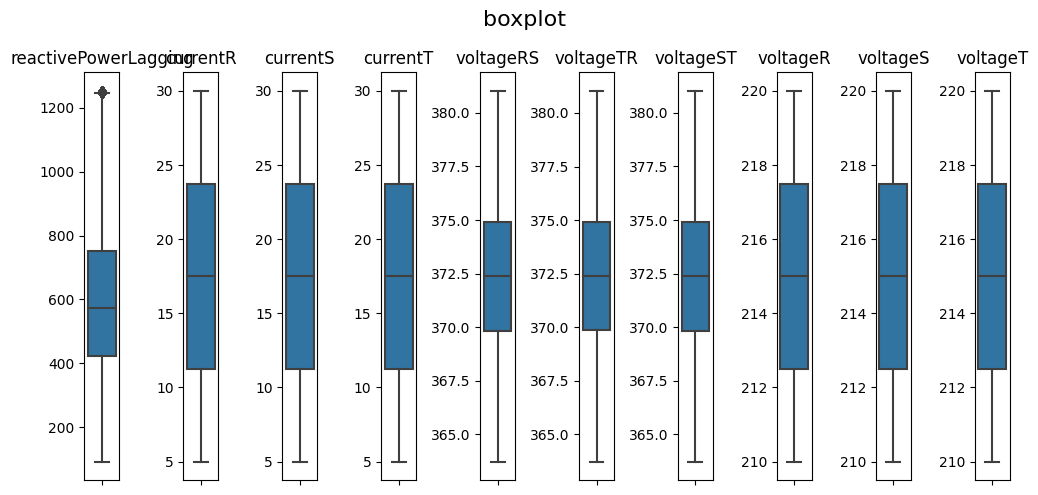

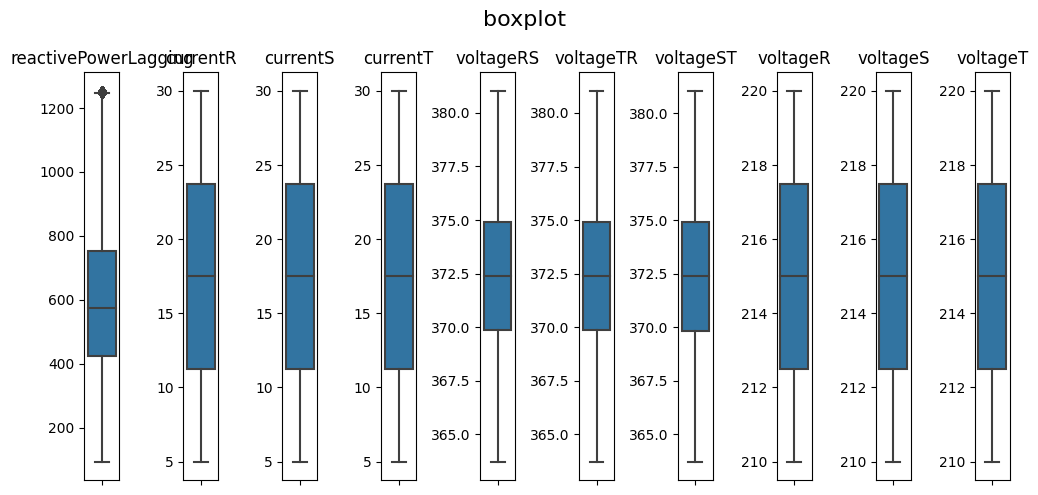

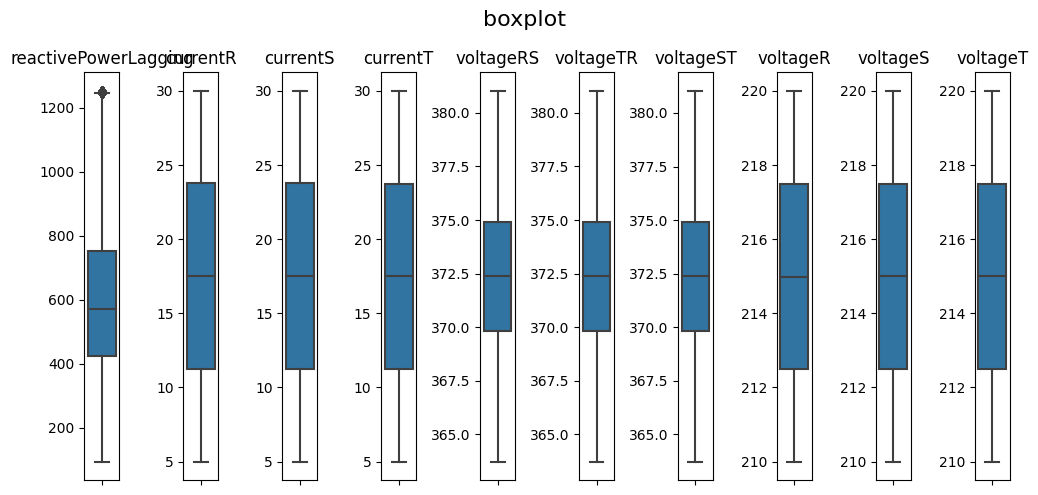

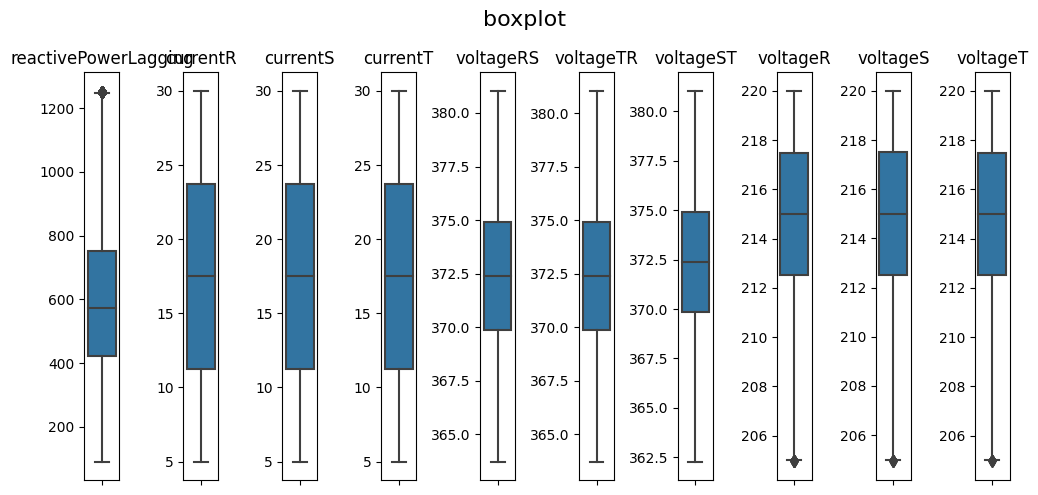

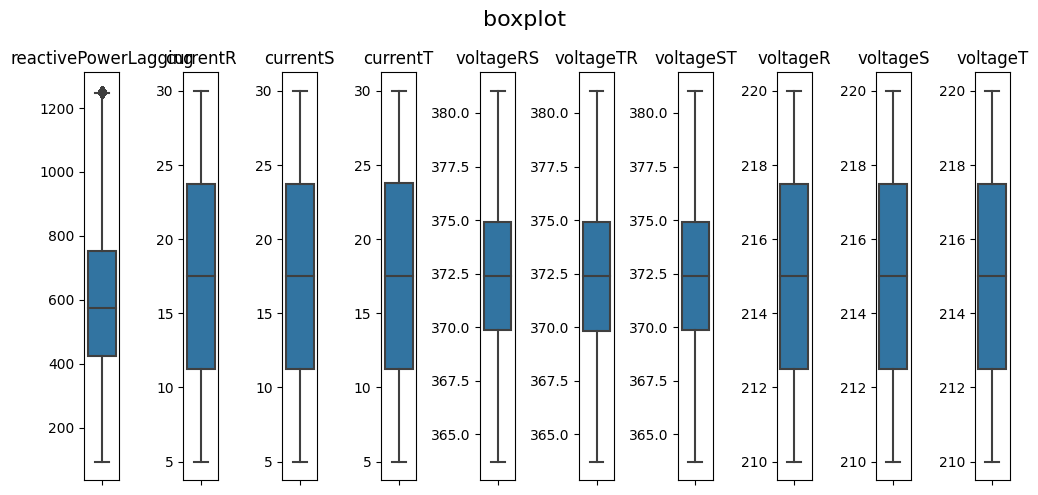

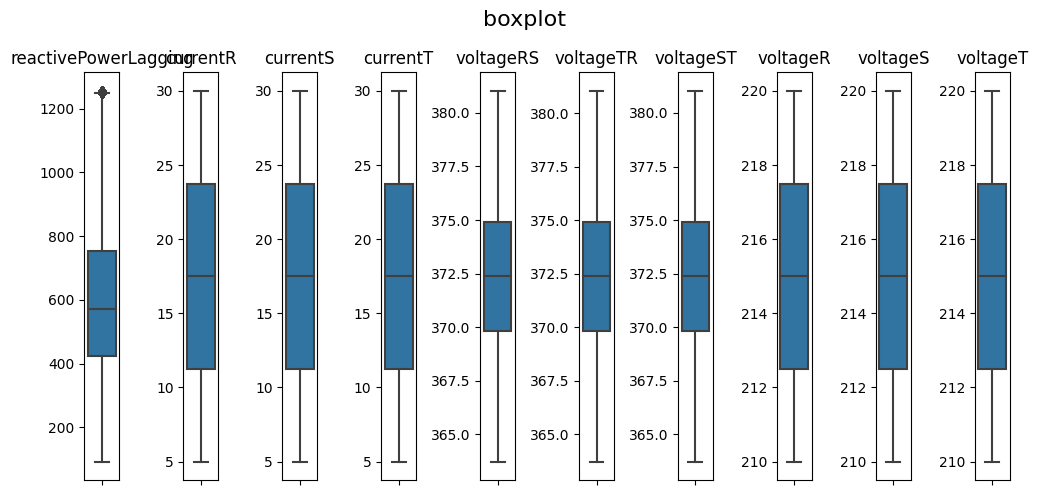

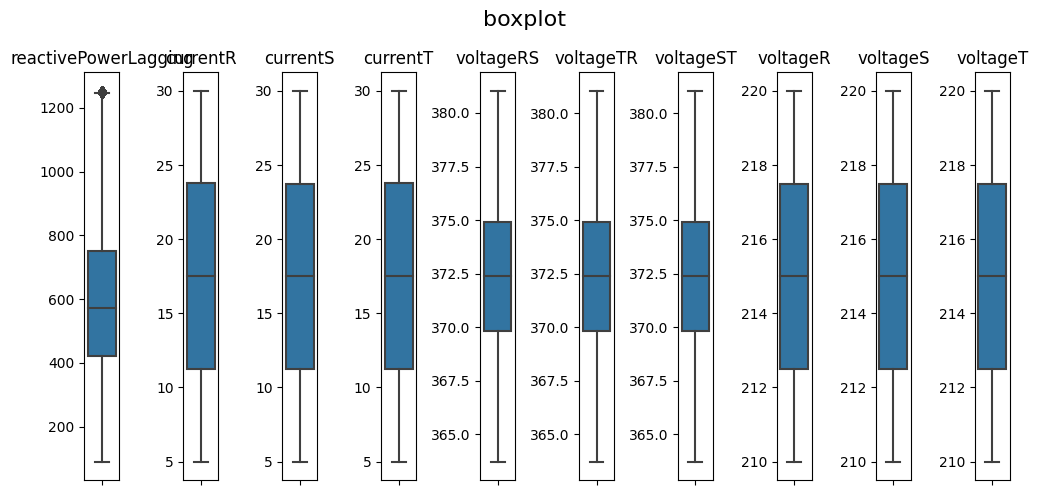

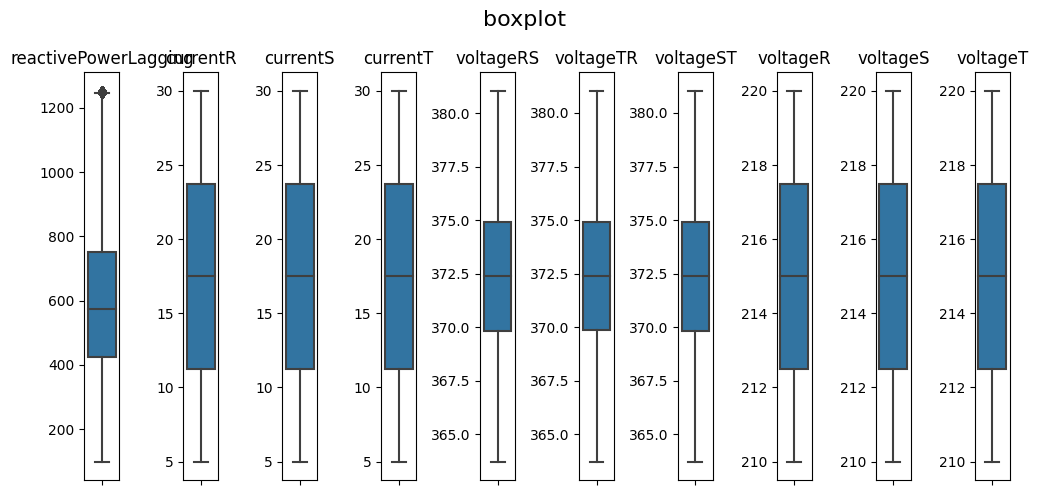

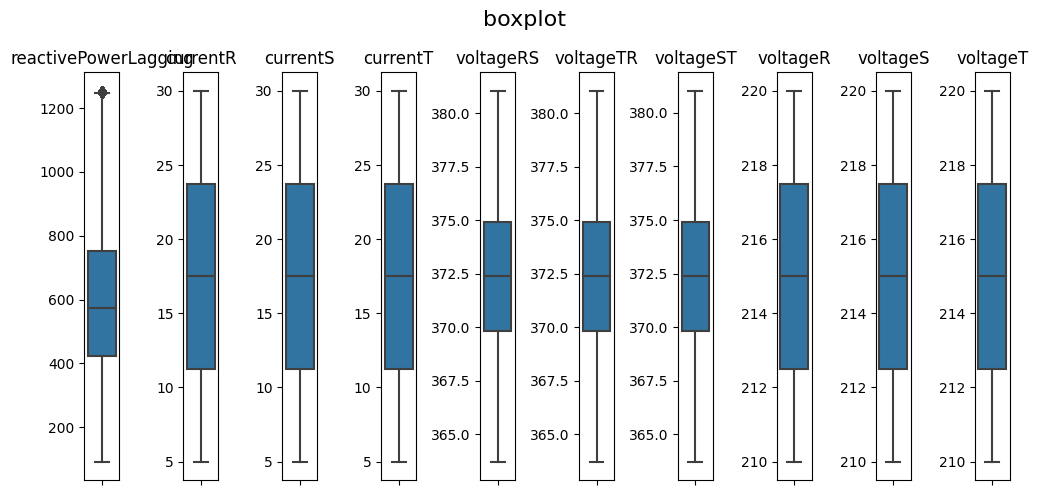

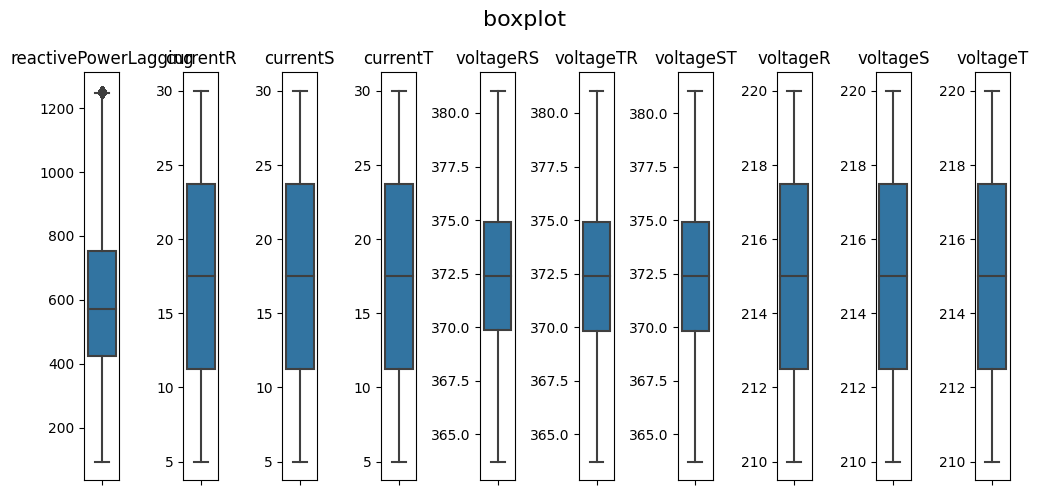

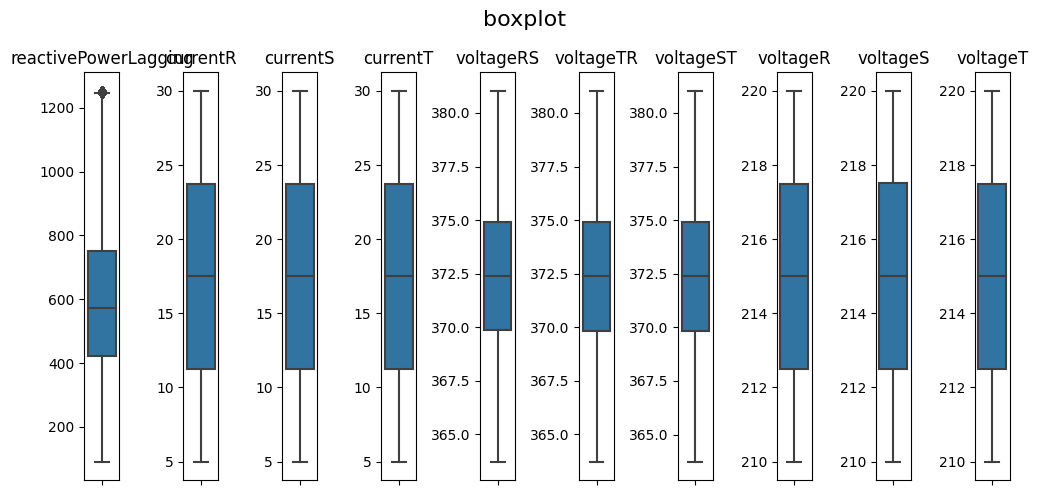

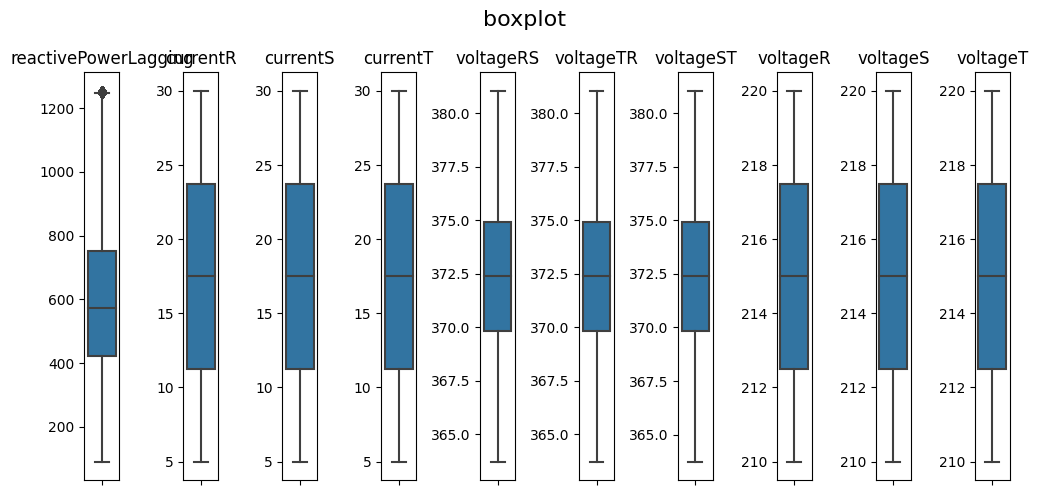

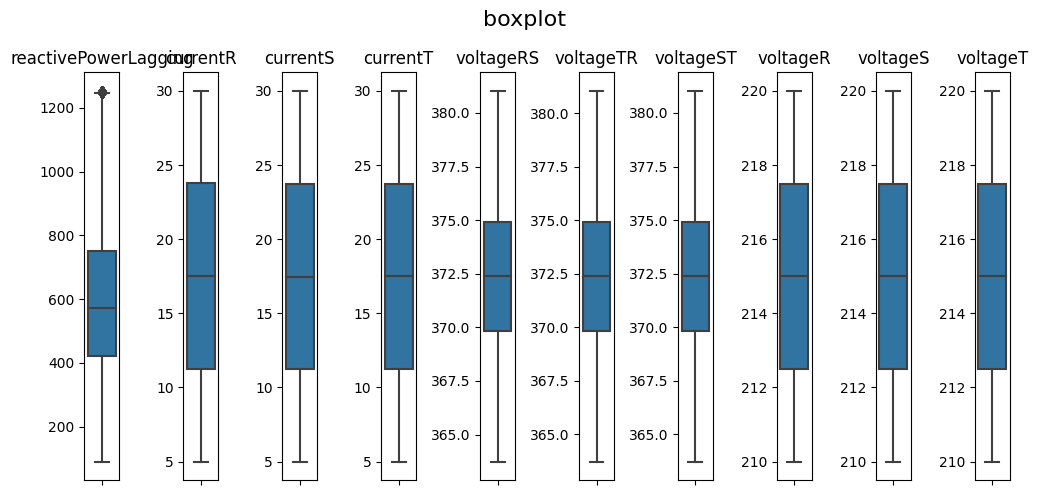

In [24]:
for mod, mod_df in df.groupby(level=0):
    plot_boxplots(mod_df[top_10_features])

In [ ]:
# try:
#     for module, df_mod in module_data.items():
#         print(module)
#         df_mod = replace_outliers_with_interpolation_v2(df_mod, corr_feature)
#         module_data[module] = df_mod  # ✅ 반영
# except Exception as e:
#     print(e)

In [ ]:
# box plot
def plot_boxplots(df, title='boxplot'):
    num_columns = len(df.columns)
    fig, axes = plt.subplots(nrows=1, ncols = num_columns, figsize=(10, 5))
    fig.suptitle(title, fontsize=16)

    axes = axes.flatten()  # 서브플롯을 1차원 배열로 변환

    for i, column in enumerate(df.columns):
        sns.boxplot(y=df[column], ax=axes[i])
        axes[i].set_title(column)
        axes[i].set_ylabel('')

    # 빈 서브플롯 숨기기
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()  # 제목 공간 확보
    plt.show()

In [ ]:
try:
    for module, df_mod in module_data.items():
        print(f"Module: {module}, Length: {len(df_mod)}")
except Exception as e:
    print(e)

# 시계열 분해 진행

In [26]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(ts, signif=0.05):
    """
    시계열 정상성 검정을 수행합니다 (Augmented Dickey-Fuller Test).

    Parameters:
    - ts: pandas Series, 시계열 데이터
    - signif: 유의수준 (기본 0.05)

    Returns:
    - dict: ADF 통계량, p-value, 정상성 여부 등
    """
    adf_result = adfuller(ts.dropna())

    output = {
        'ADF Statistic': adf_result[0],
        'p-value': adf_result[1],
        'Critical Values': adf_result[4],
        'Is Stationary': adf_result[1] < signif
    }

    print(f"ADF Statistic: {output['ADF Statistic']:.4f}")
    print(f"p-value: {output['p-value']:.4f}")
    for key, val in output['Critical Values'].items():
        print(f"Critical Value ({key}): {val:.4f}")
    print("=> The series is {}stationary at the {:.2f} significance level.".format(
        '' if output['Is Stationary'] else 'not ', signif))

    return output

In [24]:
from statsmodels.tsa.seasonal import seasonal_decompose

def downsample_and_decompose(df, module_name, 
                              target_col='activePower', 
                              resample_rule='1H', 
                              period=24, 
                              freq_label='1 Hour Average'):
    """
    5초 간격 데이터를 다운샘플링하여 시계열 분해를 수행하고 시각화합니다.

    Parameters:
    - df: 원본 DataFrame (timestamp 컬럼 포함)
    - module_name: 모듈 이름 (그래프 제목용)
    - target_col: 분석할 컬럼명 (기본값: 'activePower')
    - resample_rule: 리샘플링 주기 (예: '1H' = 1시간 평균)
    - period: seasonal_decompose 주기 (예: 24시간이면 24)
    - freq_label: 시각화 제목에 쓸 주기 이름
    """
    print(f"\n📊 Decomposing {freq_label} for module: {module_name}")

    # 다운샘플링 (예: 1시간 평균)
    ts = df[target_col].resample(resample_rule).mean().dropna()

    # 최소 2 * period 이상 필요
    if len(ts) < 2 * period:
        print(f"⚠️ Not enough data for {freq_label} decomposition (Need at least {2 * period}, got {len(ts)})")
        return

    # 시계열 분해
    result = seasonal_decompose(ts, model='additive', period=period)
        
    # 시각화
    fig = result.plot()
    fig.set_size_inches(12, 8)
    fig.suptitle(f"[{module_name}] {freq_label} Seasonal Decomposition", fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

    return result


📊 Decomposing 1 Hour Avg (Daily) for module: 1


/tmp/ipykernel_35/2232643761.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ts = df[target_col].resample(resample_rule).mean().dropna()
/tmp/ipykernel_35/2232643761.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


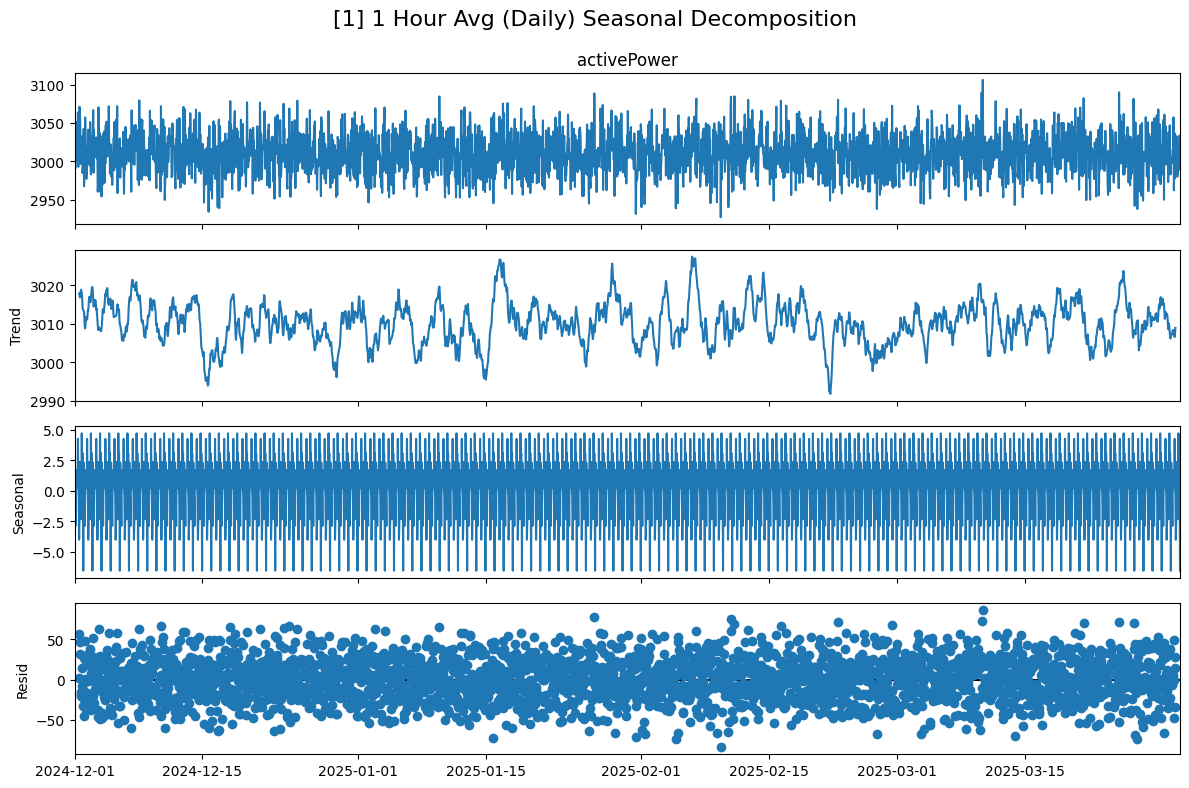


📊 Decomposing 1 Day Avg (Weekly) for module: activePower


/tmp/ipykernel_35/2232643761.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


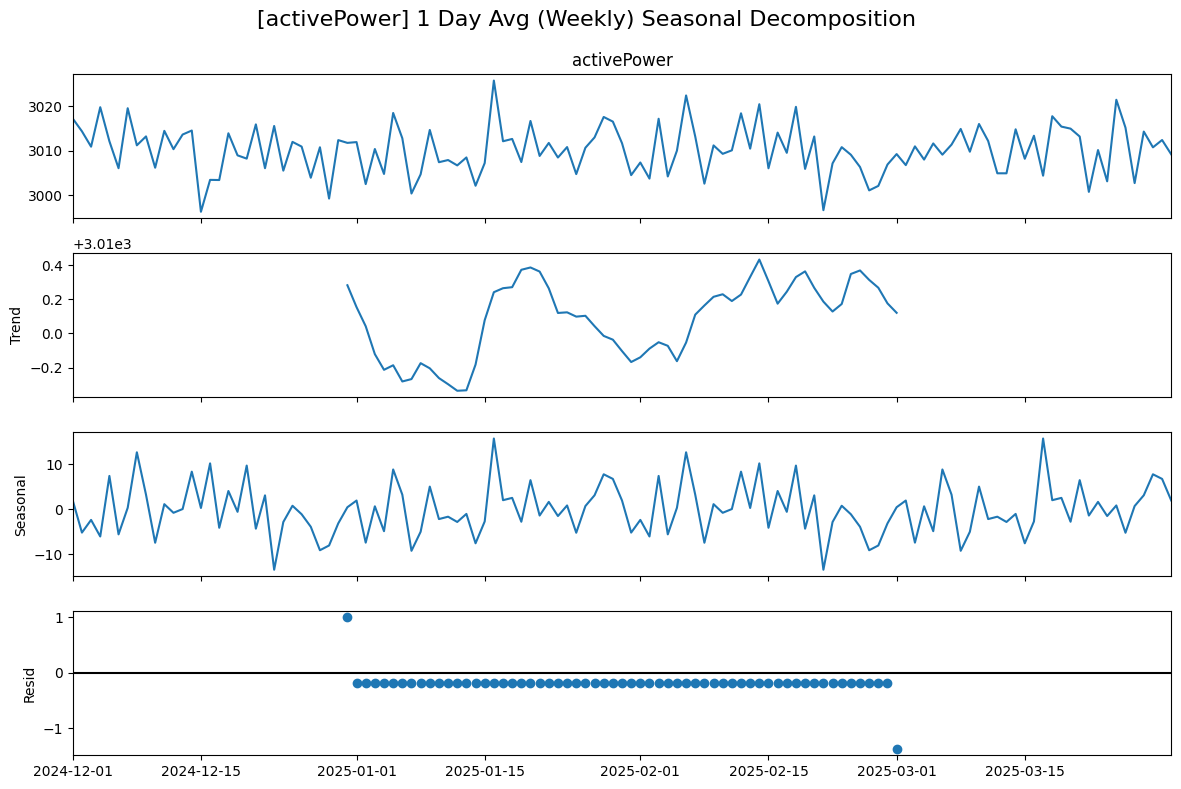

ADF Statistic: -19.3602
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8626
Critical Value (10%): -2.5673
=> The series is stationary at the 0.05 significance level.
ADF Statistic: -52.9875
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8625
Critical Value (10%): -2.5673
=> The series is stationary at the 0.05 significance level.

📊 Decomposing 1 Hour Avg (Daily) for module: 11


/tmp/ipykernel_35/2232643761.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ts = df[target_col].resample(resample_rule).mean().dropna()
/tmp/ipykernel_35/2232643761.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


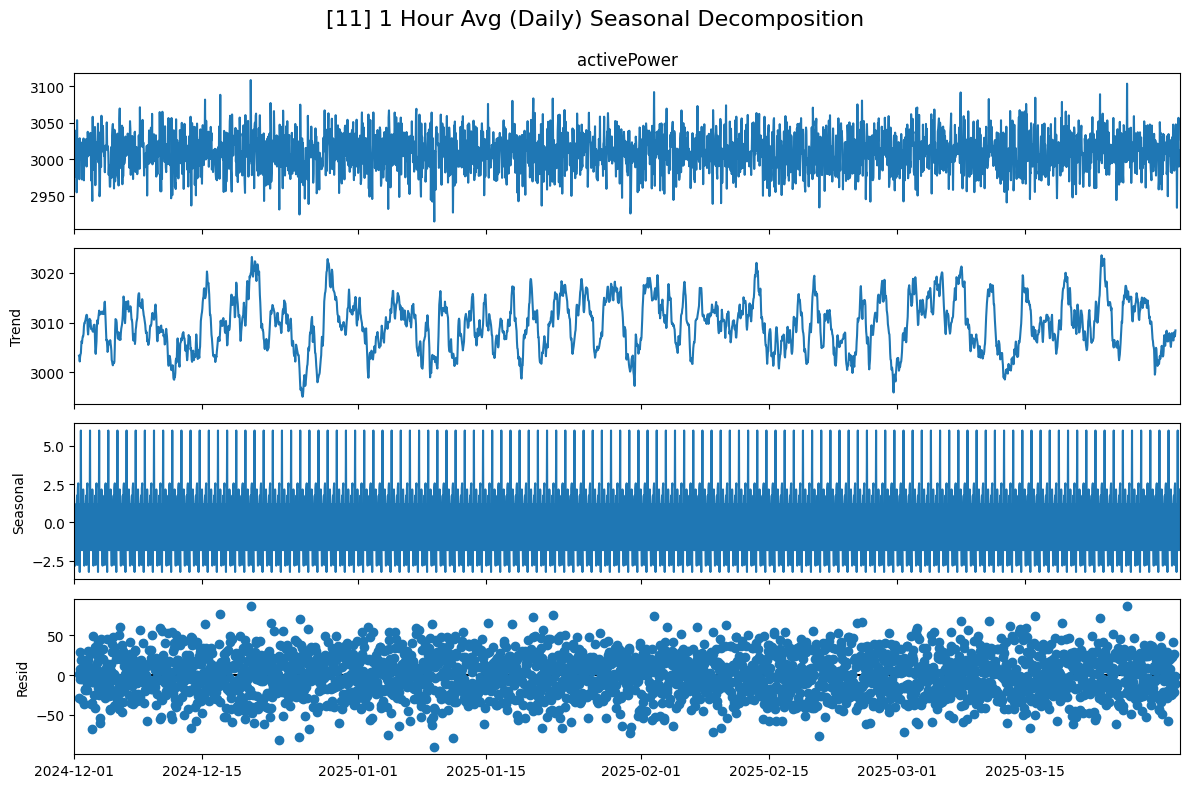


📊 Decomposing 1 Day Avg (Weekly) for module: activePower


/tmp/ipykernel_35/2232643761.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


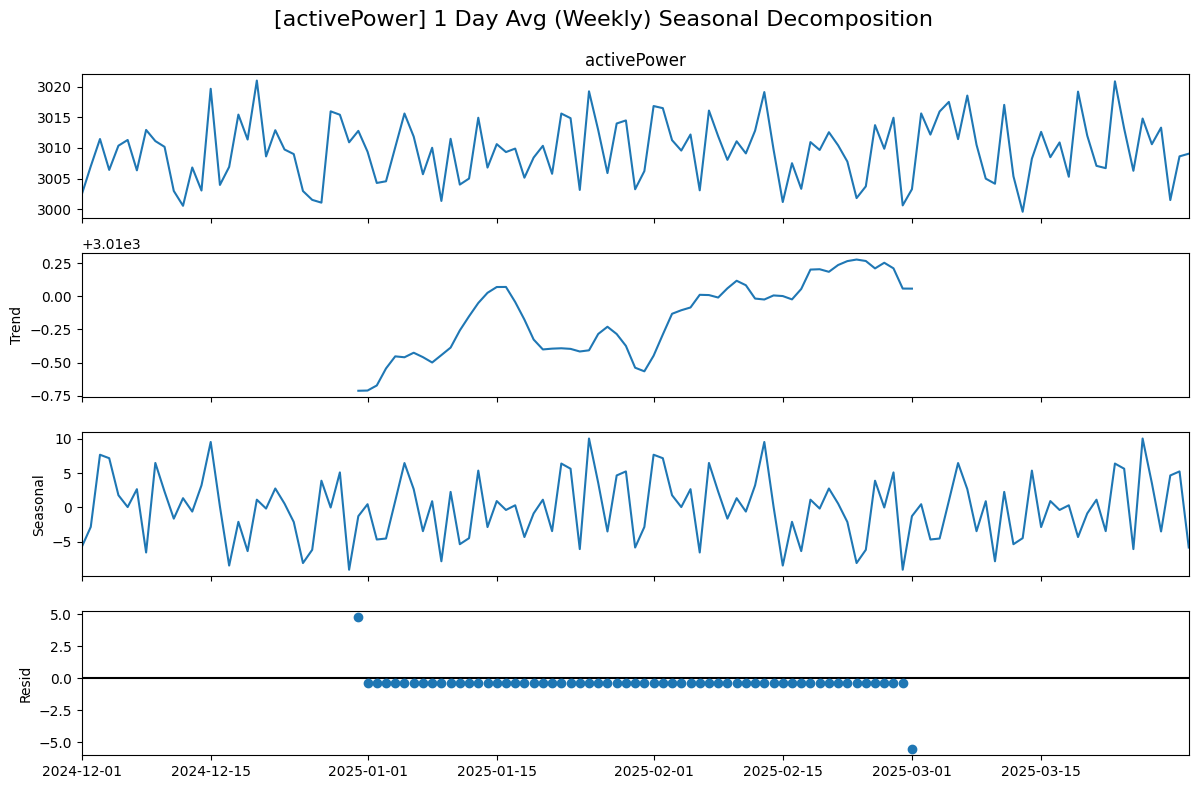

ADF Statistic: -18.6085
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8626
Critical Value (10%): -2.5673
=> The series is stationary at the 0.05 significance level.
ADF Statistic: -53.5973
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8625
Critical Value (10%): -2.5673
=> The series is stationary at the 0.05 significance level.

📊 Decomposing 1 Hour Avg (Daily) for module: 12


/tmp/ipykernel_35/2232643761.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ts = df[target_col].resample(resample_rule).mean().dropna()
/tmp/ipykernel_35/2232643761.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


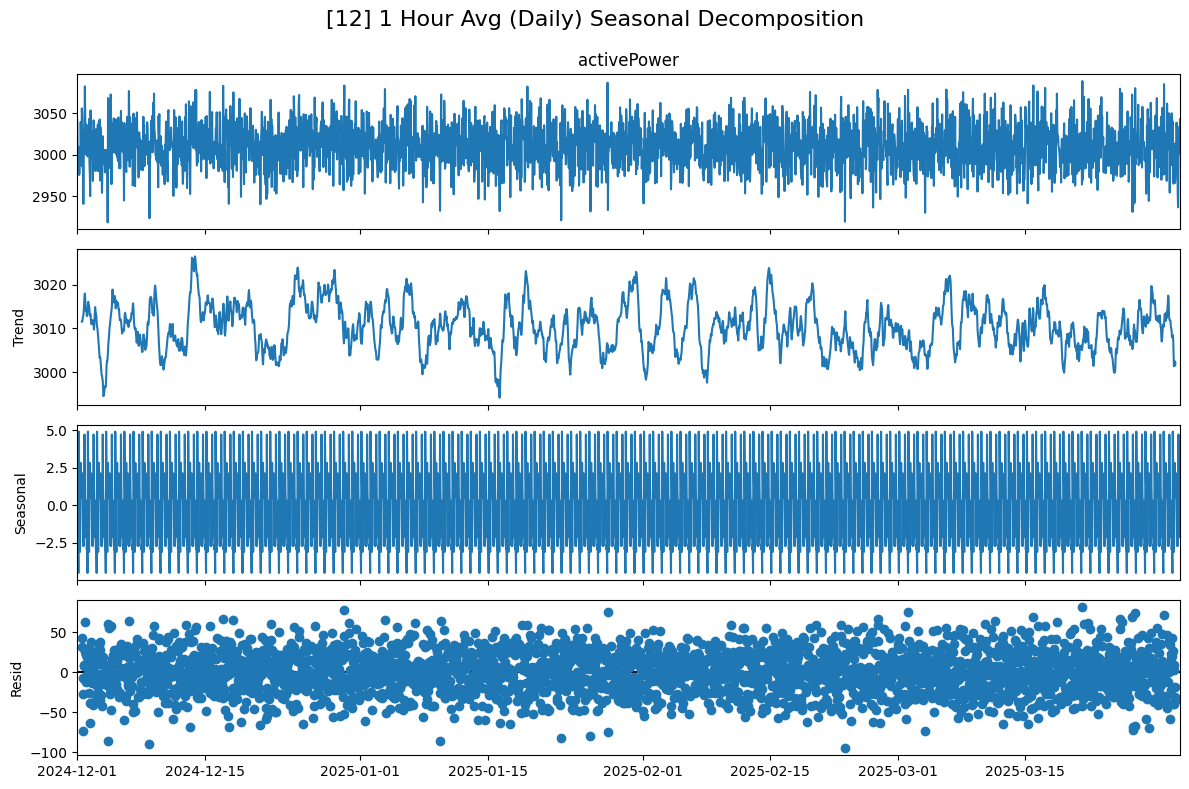


📊 Decomposing 1 Day Avg (Weekly) for module: activePower


/tmp/ipykernel_35/2232643761.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


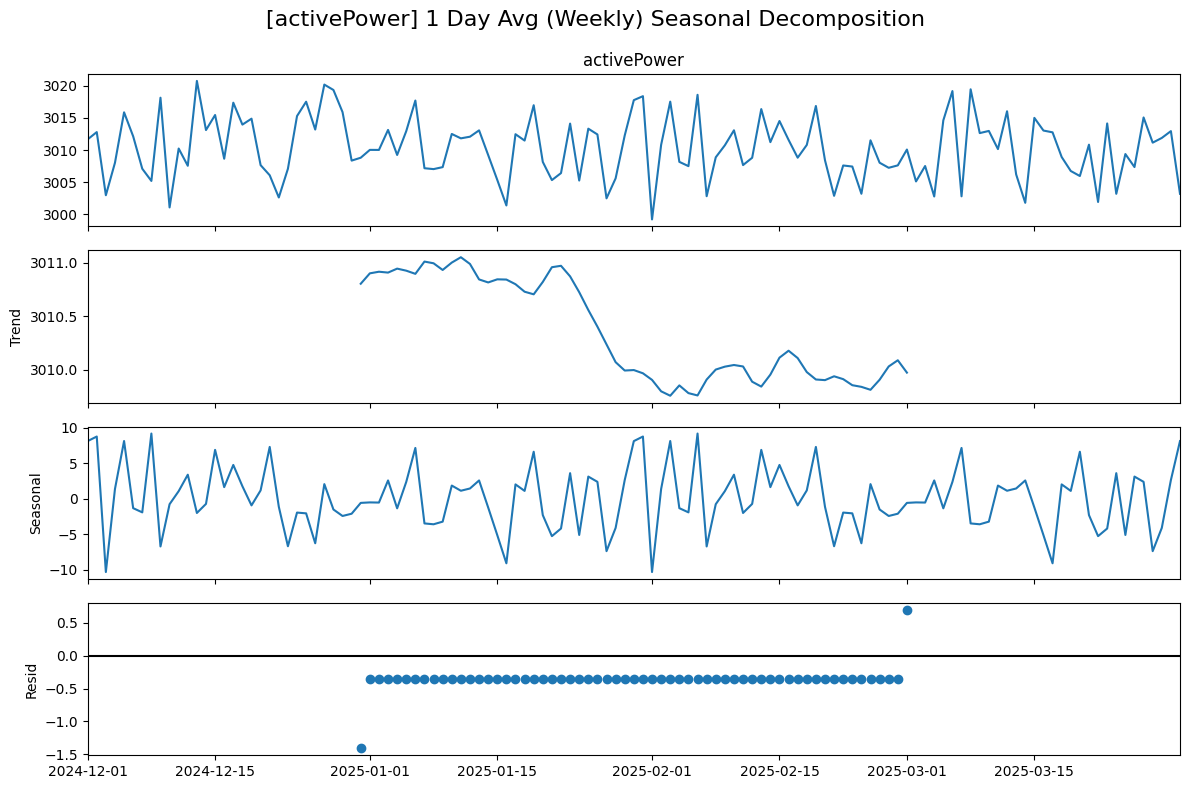

ADF Statistic: -18.4197
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8626
Critical Value (10%): -2.5673
=> The series is stationary at the 0.05 significance level.
ADF Statistic: -53.9715
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8625
Critical Value (10%): -2.5673
=> The series is stationary at the 0.05 significance level.

📊 Decomposing 1 Hour Avg (Daily) for module: 13


/tmp/ipykernel_35/2232643761.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ts = df[target_col].resample(resample_rule).mean().dropna()
/tmp/ipykernel_35/2232643761.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


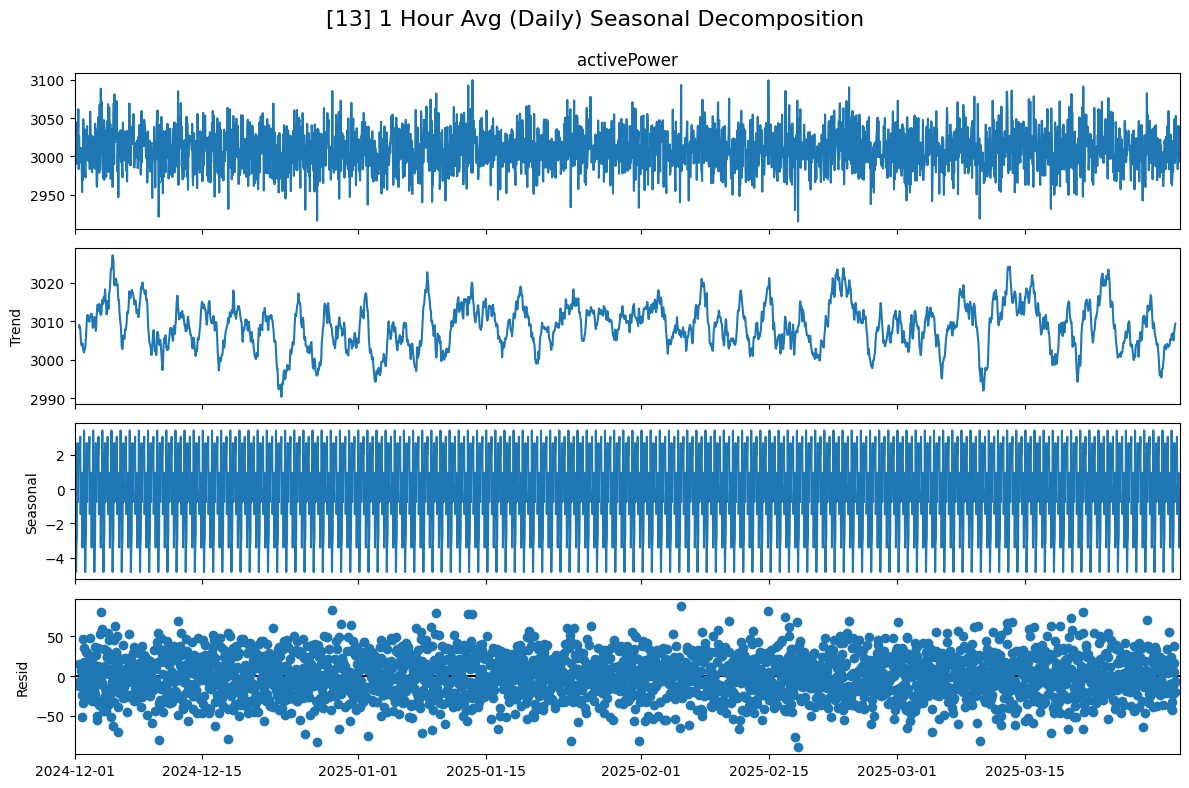


📊 Decomposing 1 Day Avg (Weekly) for module: activePower


/tmp/ipykernel_35/2232643761.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


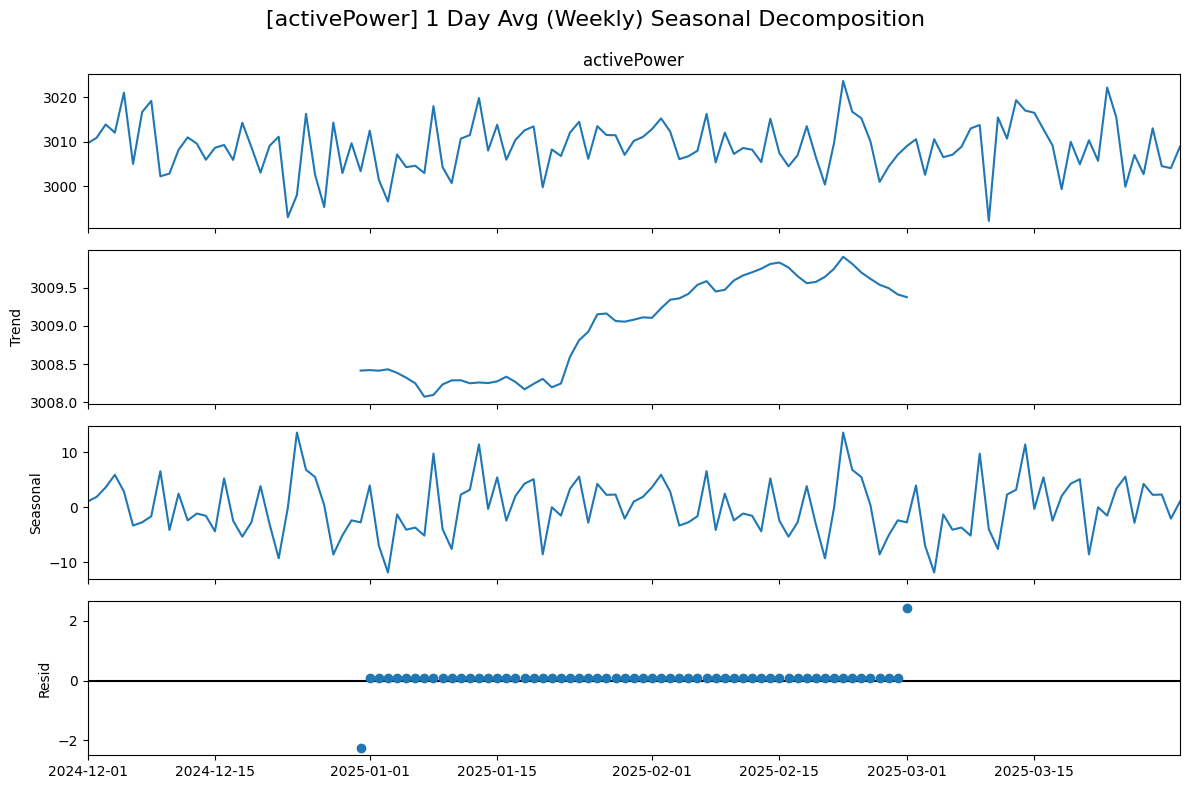

ADF Statistic: -19.1432
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8626
Critical Value (10%): -2.5673
=> The series is stationary at the 0.05 significance level.
ADF Statistic: -52.4586
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8625
Critical Value (10%): -2.5673
=> The series is stationary at the 0.05 significance level.

📊 Decomposing 1 Hour Avg (Daily) for module: 14


/tmp/ipykernel_35/2232643761.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ts = df[target_col].resample(resample_rule).mean().dropna()
/tmp/ipykernel_35/2232643761.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


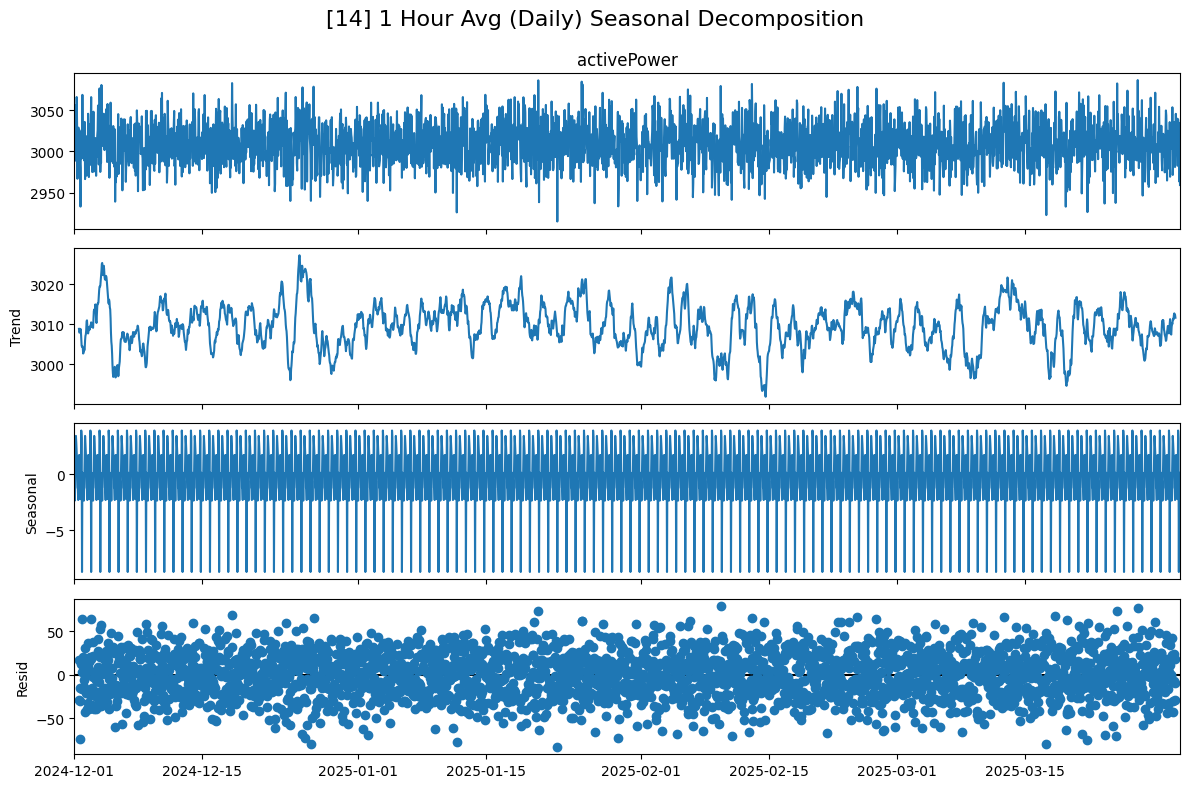


📊 Decomposing 1 Day Avg (Weekly) for module: activePower


/tmp/ipykernel_35/2232643761.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


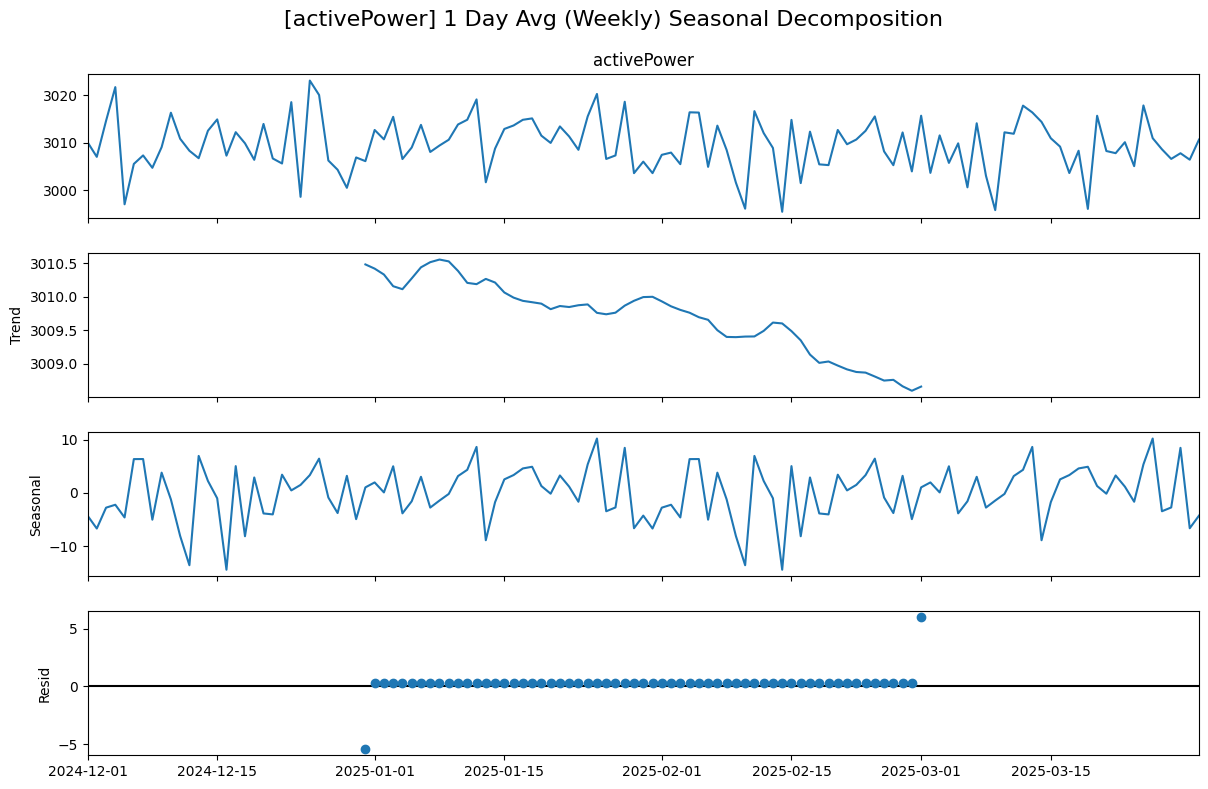

ADF Statistic: -17.6930
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8626
Critical Value (10%): -2.5673
=> The series is stationary at the 0.05 significance level.
ADF Statistic: -52.8838
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8625
Critical Value (10%): -2.5673
=> The series is stationary at the 0.05 significance level.

📊 Decomposing 1 Hour Avg (Daily) for module: 15


/tmp/ipykernel_35/2232643761.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ts = df[target_col].resample(resample_rule).mean().dropna()
/tmp/ipykernel_35/2232643761.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


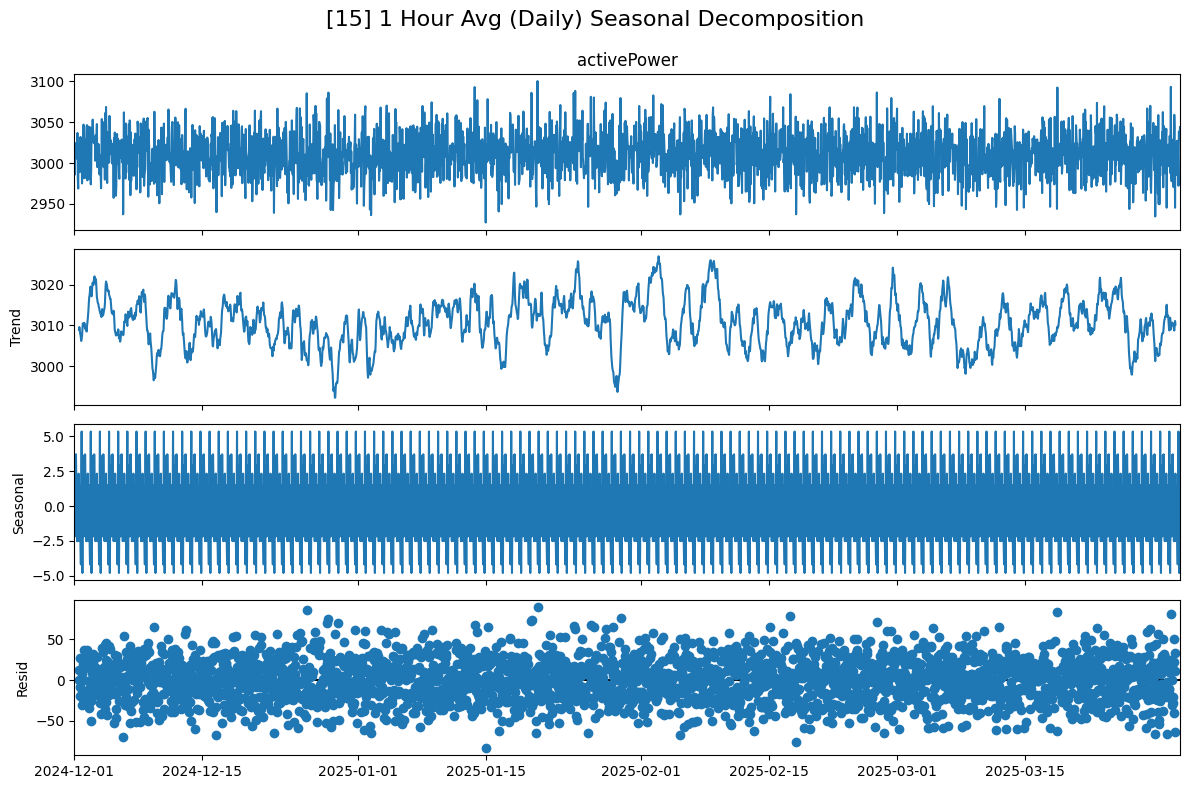


📊 Decomposing 1 Day Avg (Weekly) for module: activePower


/tmp/ipykernel_35/2232643761.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


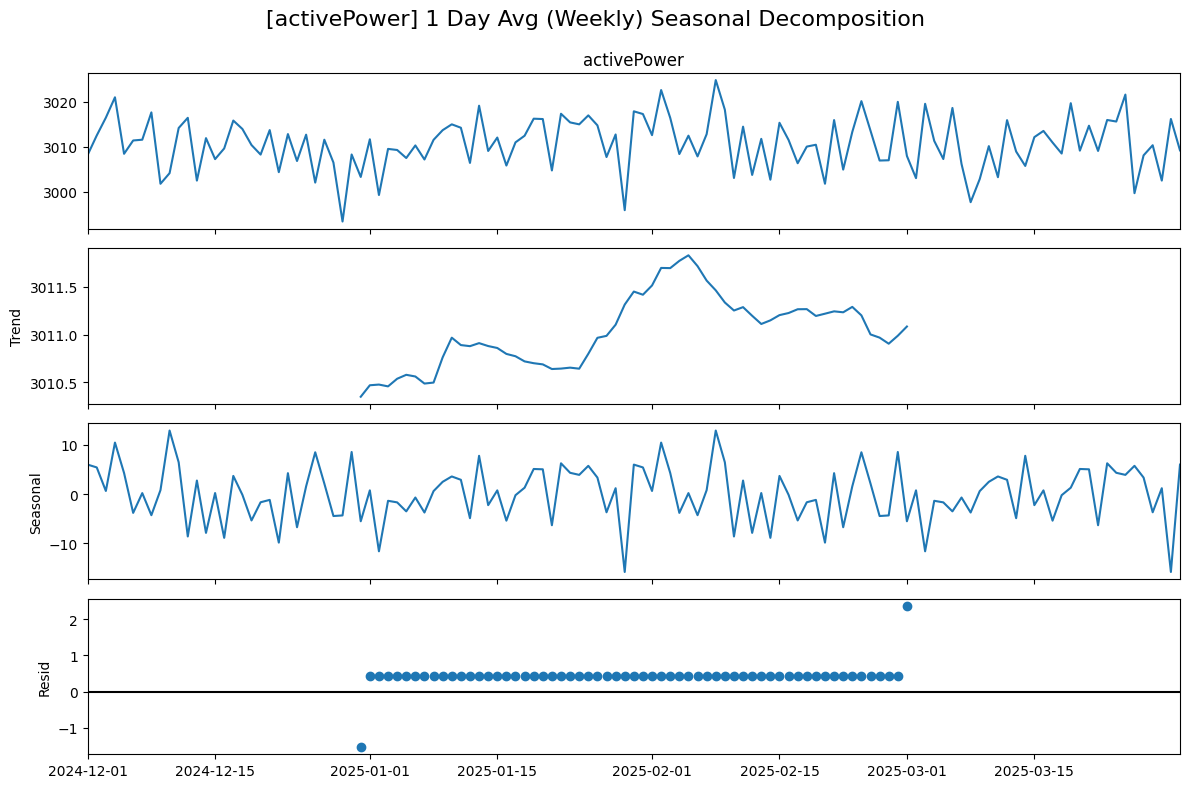

ADF Statistic: -17.5277
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8626
Critical Value (10%): -2.5673
=> The series is stationary at the 0.05 significance level.
ADF Statistic: -25.6440
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8625
Critical Value (10%): -2.5673
=> The series is stationary at the 0.05 significance level.

📊 Decomposing 1 Hour Avg (Daily) for module: 16


/tmp/ipykernel_35/2232643761.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ts = df[target_col].resample(resample_rule).mean().dropna()
/tmp/ipykernel_35/2232643761.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


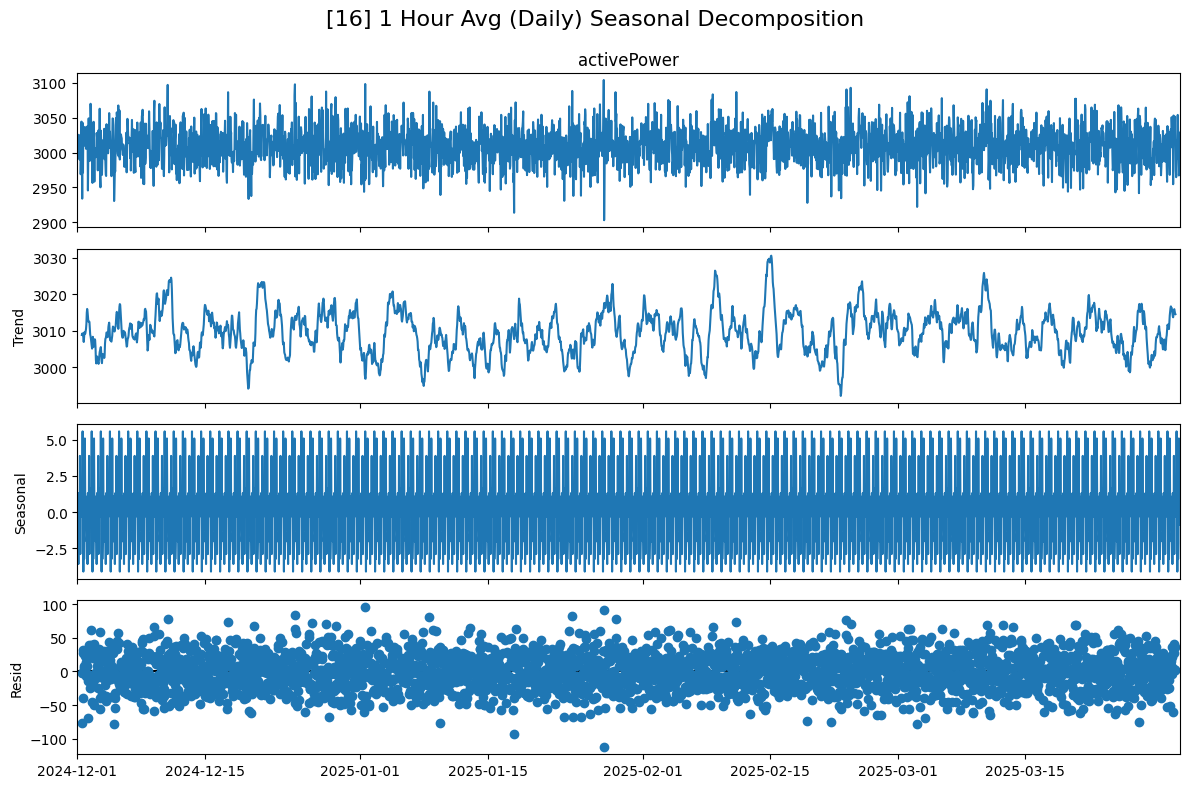


📊 Decomposing 1 Day Avg (Weekly) for module: activePower


/tmp/ipykernel_35/2232643761.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


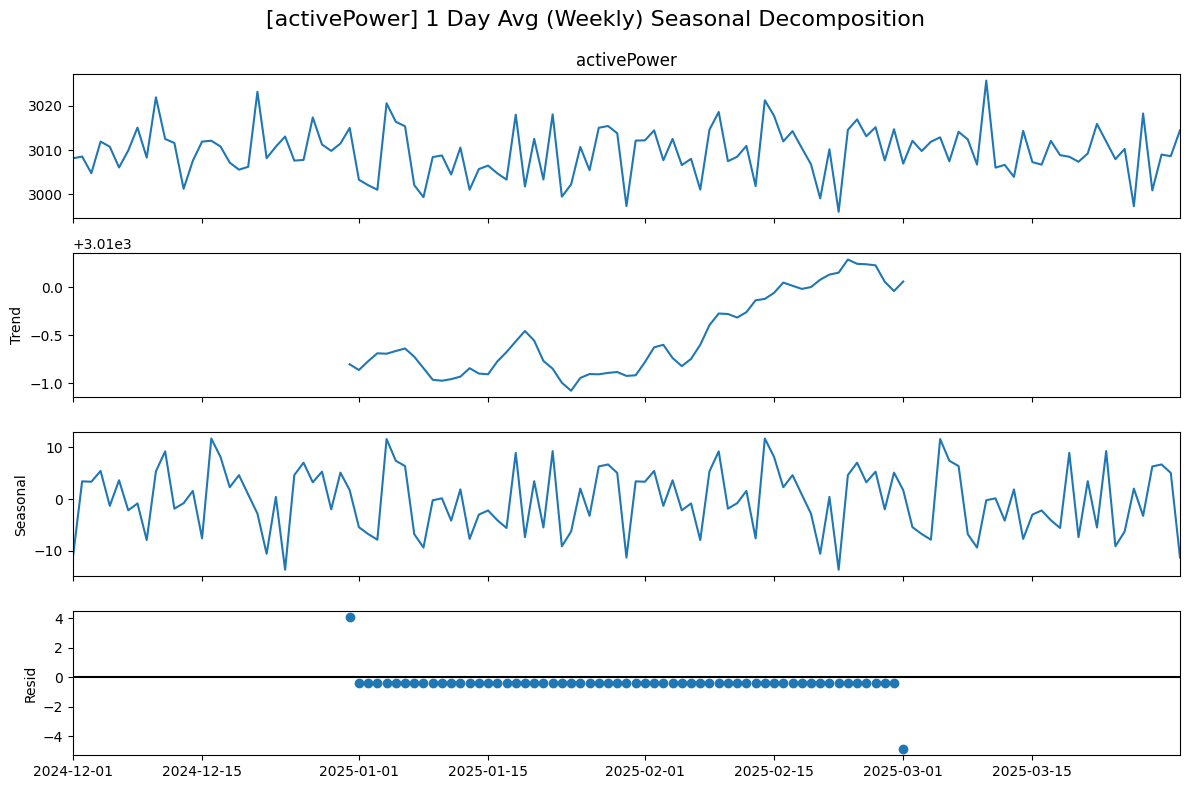

ADF Statistic: -18.3812
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8626
Critical Value (10%): -2.5673
=> The series is stationary at the 0.05 significance level.
ADF Statistic: -52.0240
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8625
Critical Value (10%): -2.5673
=> The series is stationary at the 0.05 significance level.

📊 Decomposing 1 Hour Avg (Daily) for module: 17


/tmp/ipykernel_35/2232643761.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ts = df[target_col].resample(resample_rule).mean().dropna()
/tmp/ipykernel_35/2232643761.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


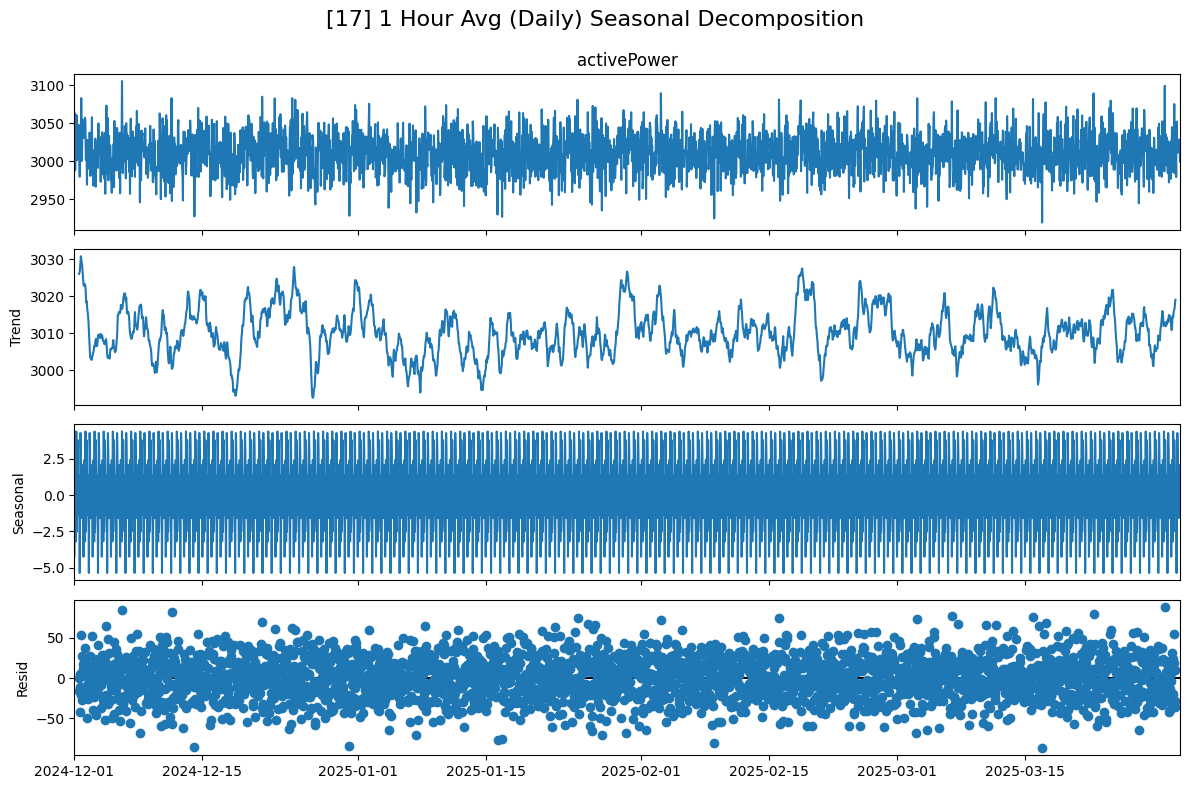


📊 Decomposing 1 Day Avg (Weekly) for module: activePower


/tmp/ipykernel_35/2232643761.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


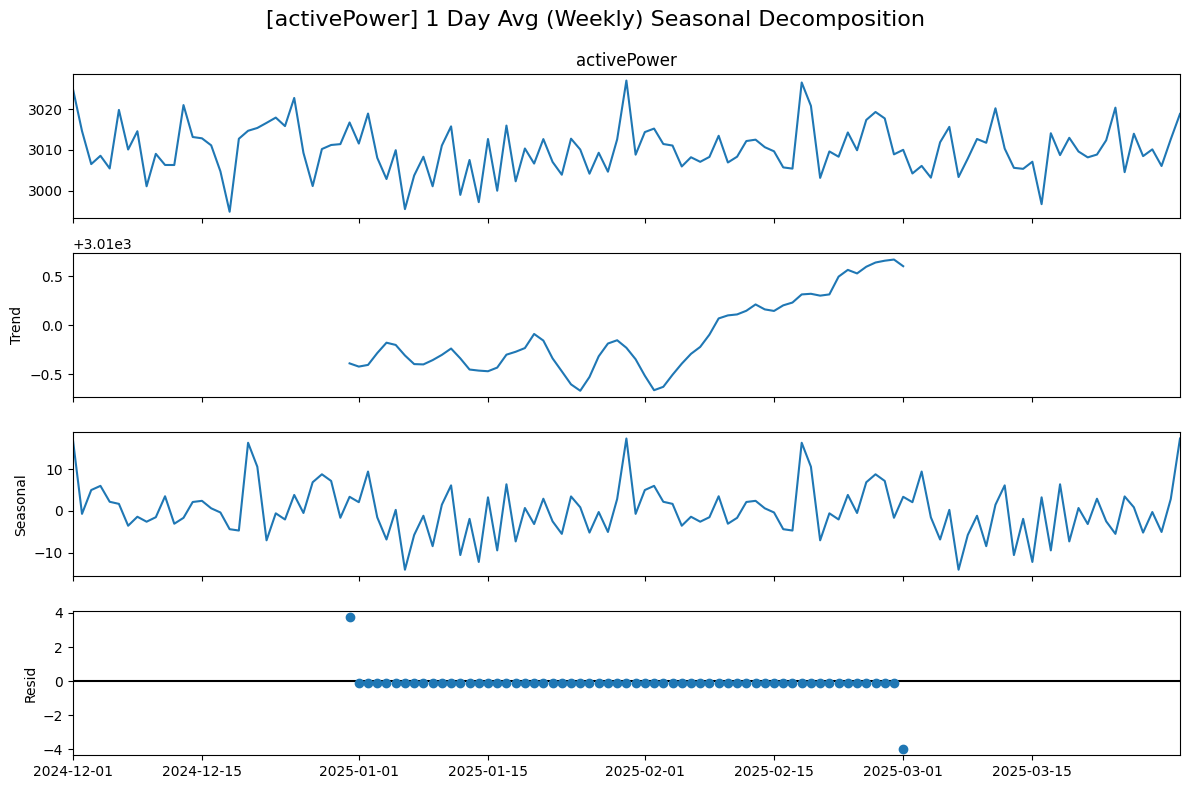

ADF Statistic: -18.8537
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8626
Critical Value (10%): -2.5673
=> The series is stationary at the 0.05 significance level.
ADF Statistic: -28.6393
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8625
Critical Value (10%): -2.5673
=> The series is stationary at the 0.05 significance level.

📊 Decomposing 1 Hour Avg (Daily) for module: 18


/tmp/ipykernel_35/2232643761.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ts = df[target_col].resample(resample_rule).mean().dropna()
/tmp/ipykernel_35/2232643761.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


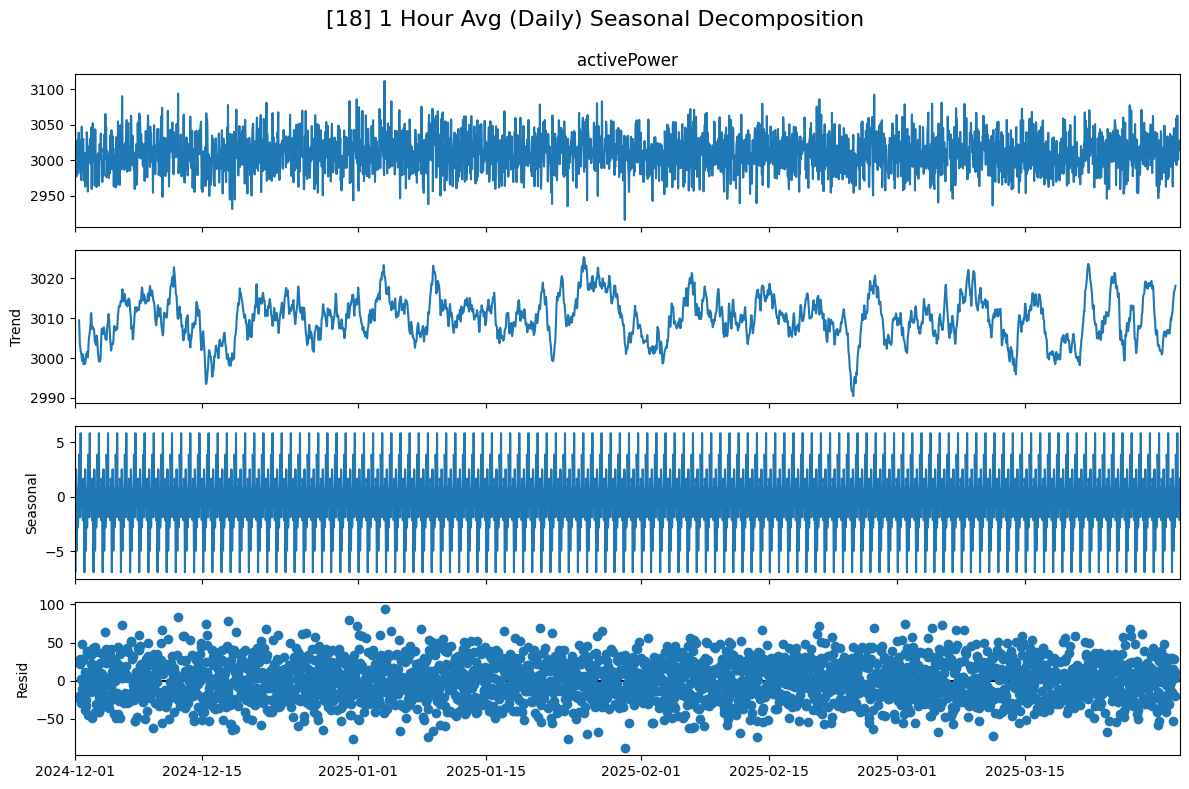


📊 Decomposing 1 Day Avg (Weekly) for module: activePower


/tmp/ipykernel_35/2232643761.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


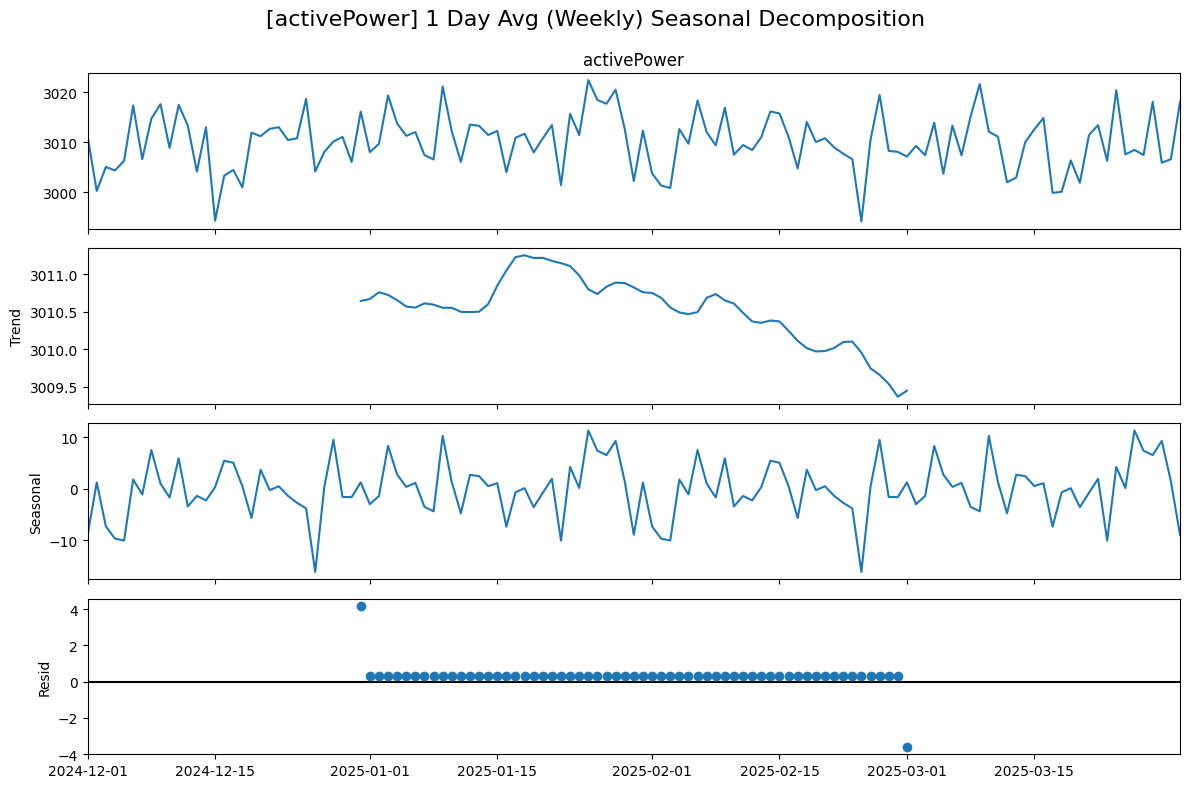

ADF Statistic: -19.0880
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8626
Critical Value (10%): -2.5673
=> The series is stationary at the 0.05 significance level.
ADF Statistic: -54.1125
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8625
Critical Value (10%): -2.5673
=> The series is stationary at the 0.05 significance level.

📊 Decomposing 1 Hour Avg (Daily) for module: 2


/tmp/ipykernel_35/2232643761.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ts = df[target_col].resample(resample_rule).mean().dropna()
/tmp/ipykernel_35/2232643761.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


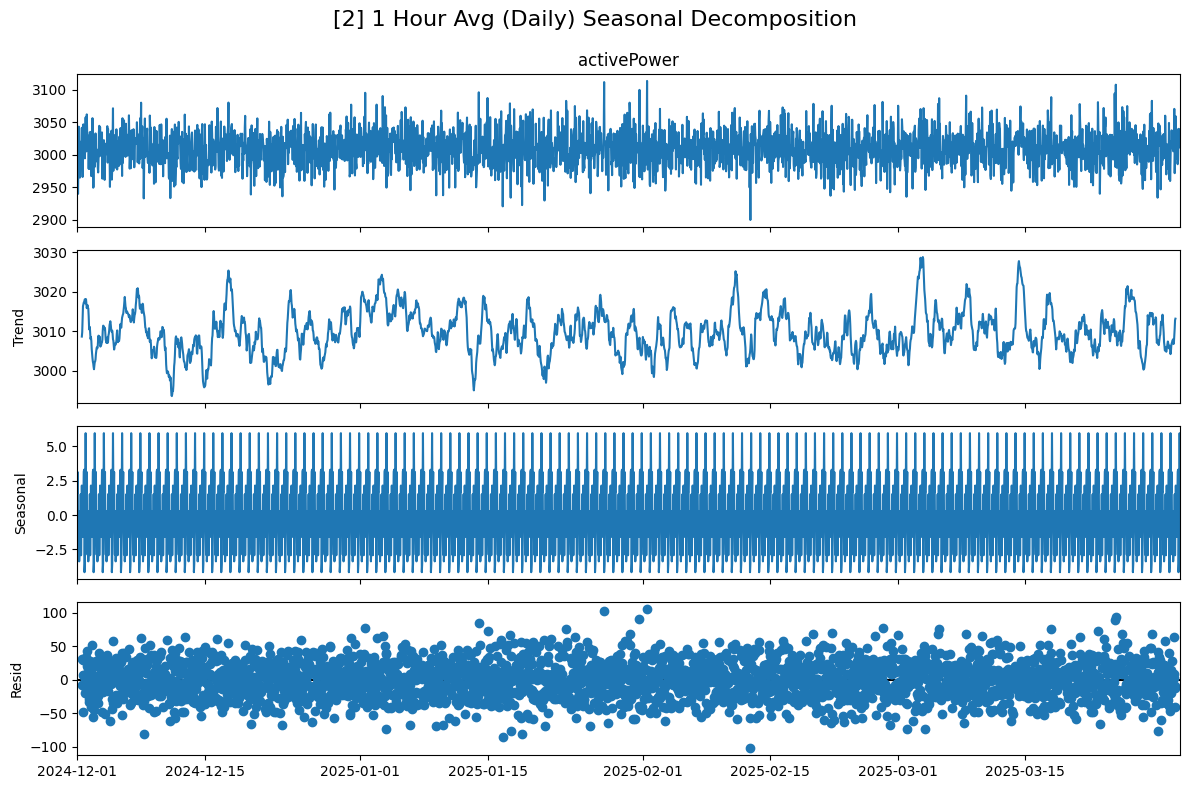


📊 Decomposing 1 Day Avg (Weekly) for module: activePower


/tmp/ipykernel_35/2232643761.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


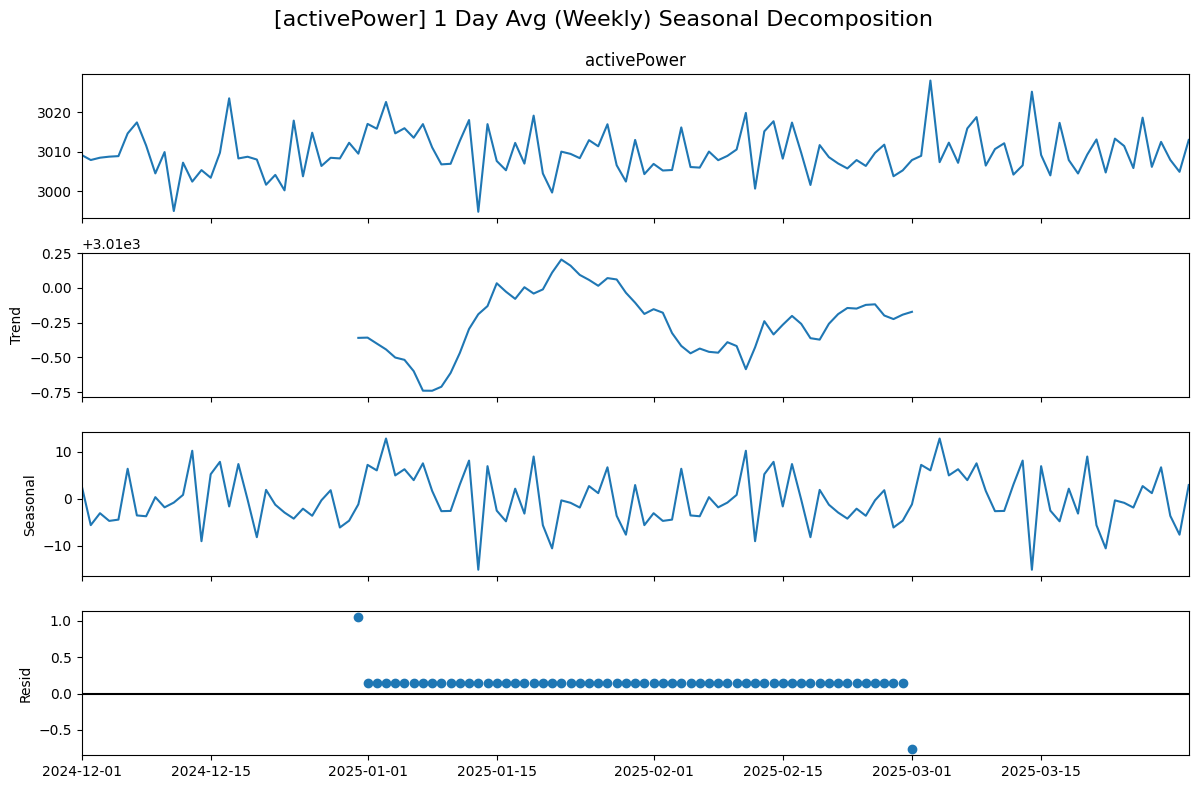

ADF Statistic: -18.8151
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8626
Critical Value (10%): -2.5673
=> The series is stationary at the 0.05 significance level.
ADF Statistic: -24.3400
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8625
Critical Value (10%): -2.5673
=> The series is stationary at the 0.05 significance level.

📊 Decomposing 1 Hour Avg (Daily) for module: 3


/tmp/ipykernel_35/2232643761.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ts = df[target_col].resample(resample_rule).mean().dropna()
/tmp/ipykernel_35/2232643761.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


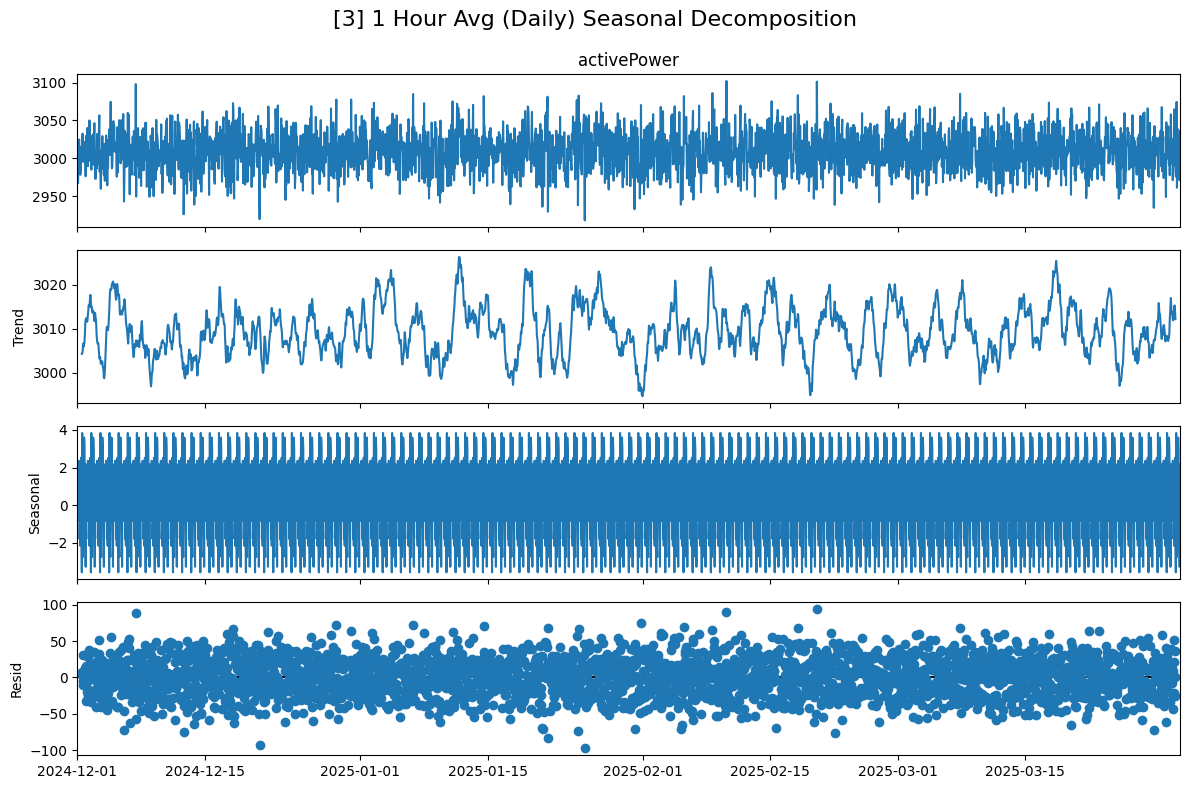


📊 Decomposing 1 Day Avg (Weekly) for module: activePower


/tmp/ipykernel_35/2232643761.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


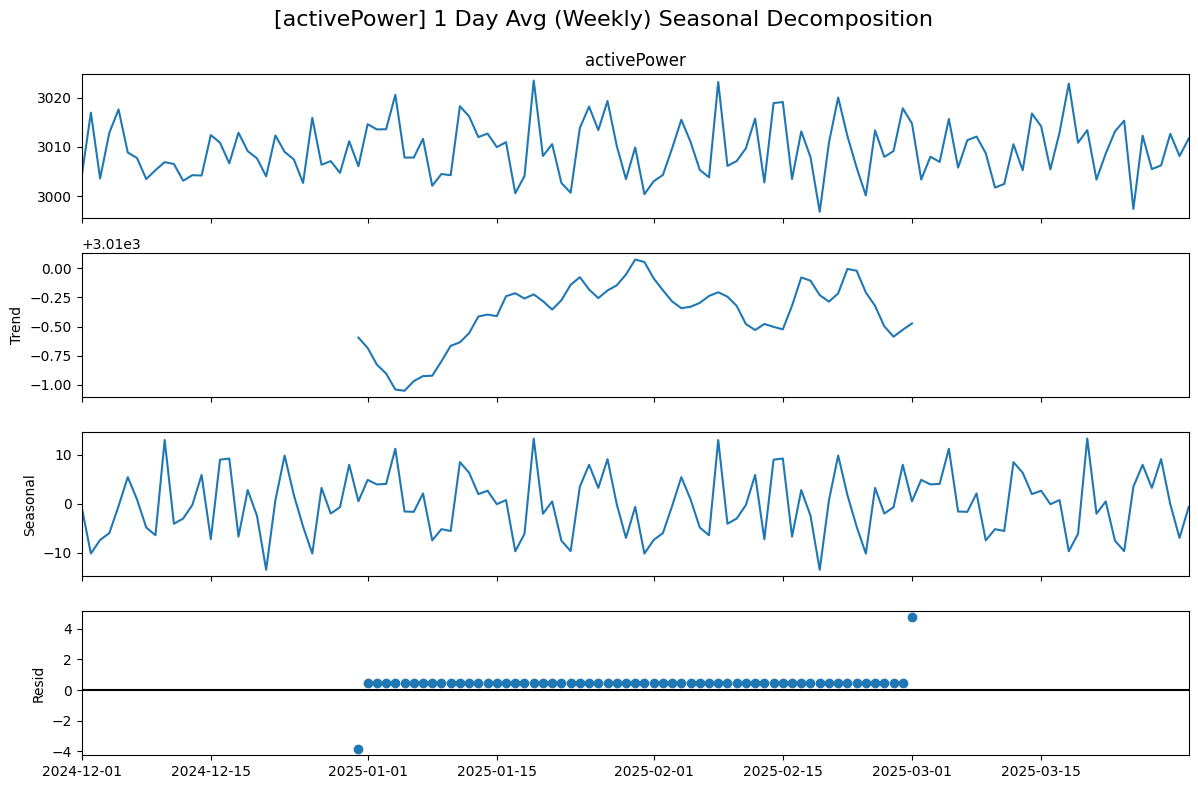

ADF Statistic: -18.6140
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8626
Critical Value (10%): -2.5673
=> The series is stationary at the 0.05 significance level.
ADF Statistic: -54.8816
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8625
Critical Value (10%): -2.5673
=> The series is stationary at the 0.05 significance level.

📊 Decomposing 1 Hour Avg (Daily) for module: 4


/tmp/ipykernel_35/2232643761.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ts = df[target_col].resample(resample_rule).mean().dropna()
/tmp/ipykernel_35/2232643761.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


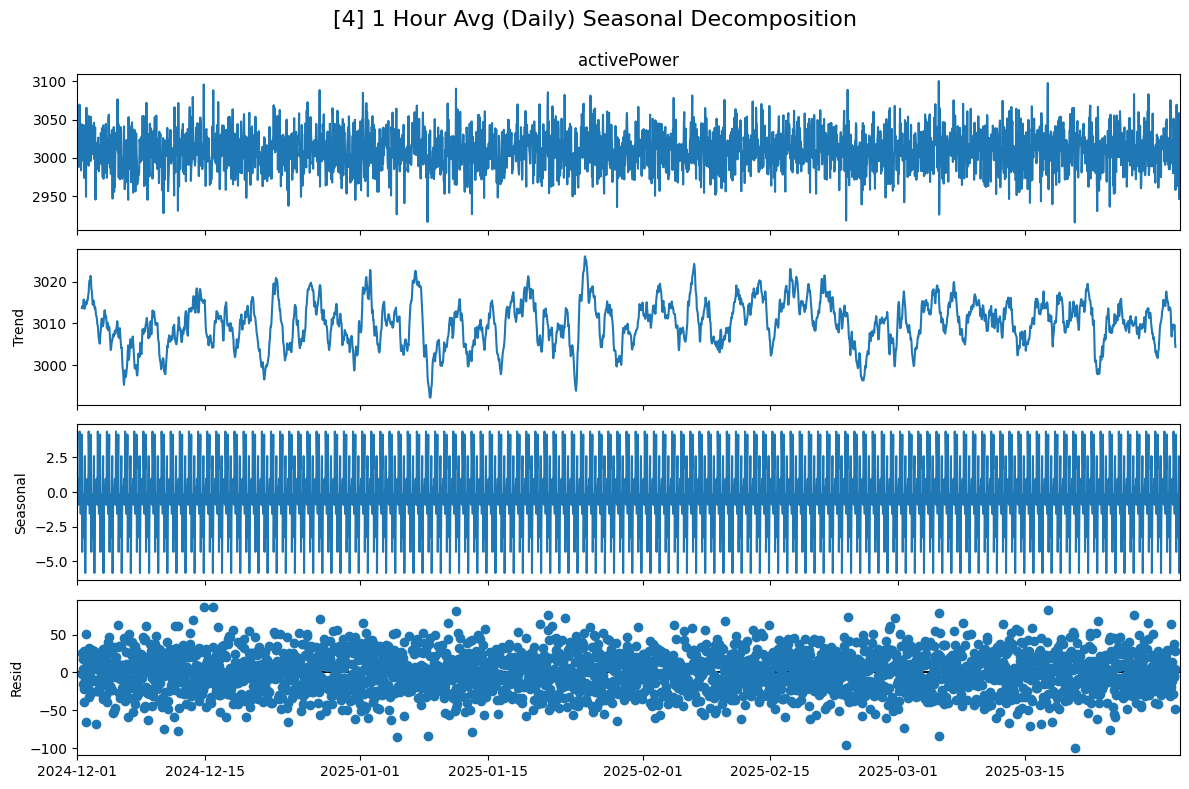


📊 Decomposing 1 Day Avg (Weekly) for module: activePower


/tmp/ipykernel_35/2232643761.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


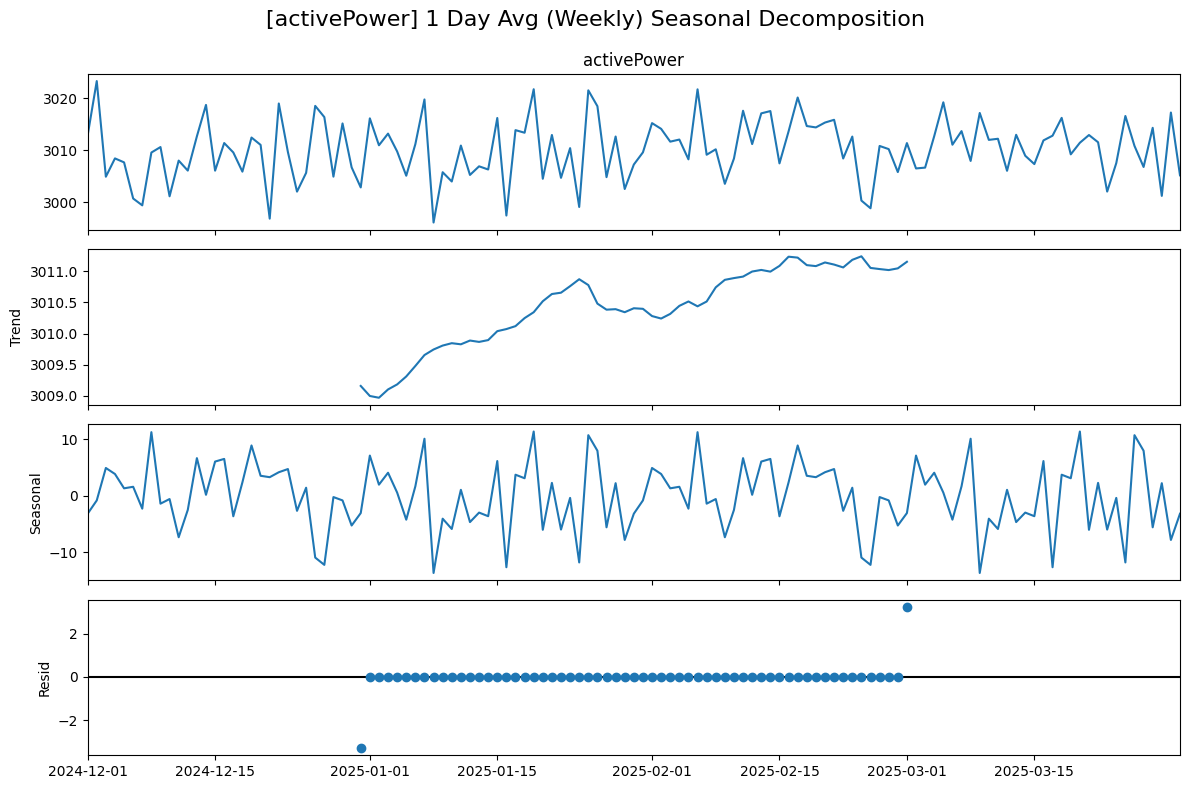

ADF Statistic: -18.7652
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8626
Critical Value (10%): -2.5673
=> The series is stationary at the 0.05 significance level.
ADF Statistic: -54.5826
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8625
Critical Value (10%): -2.5673
=> The series is stationary at the 0.05 significance level.

📊 Decomposing 1 Hour Avg (Daily) for module: 5


/tmp/ipykernel_35/2232643761.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ts = df[target_col].resample(resample_rule).mean().dropna()
/tmp/ipykernel_35/2232643761.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


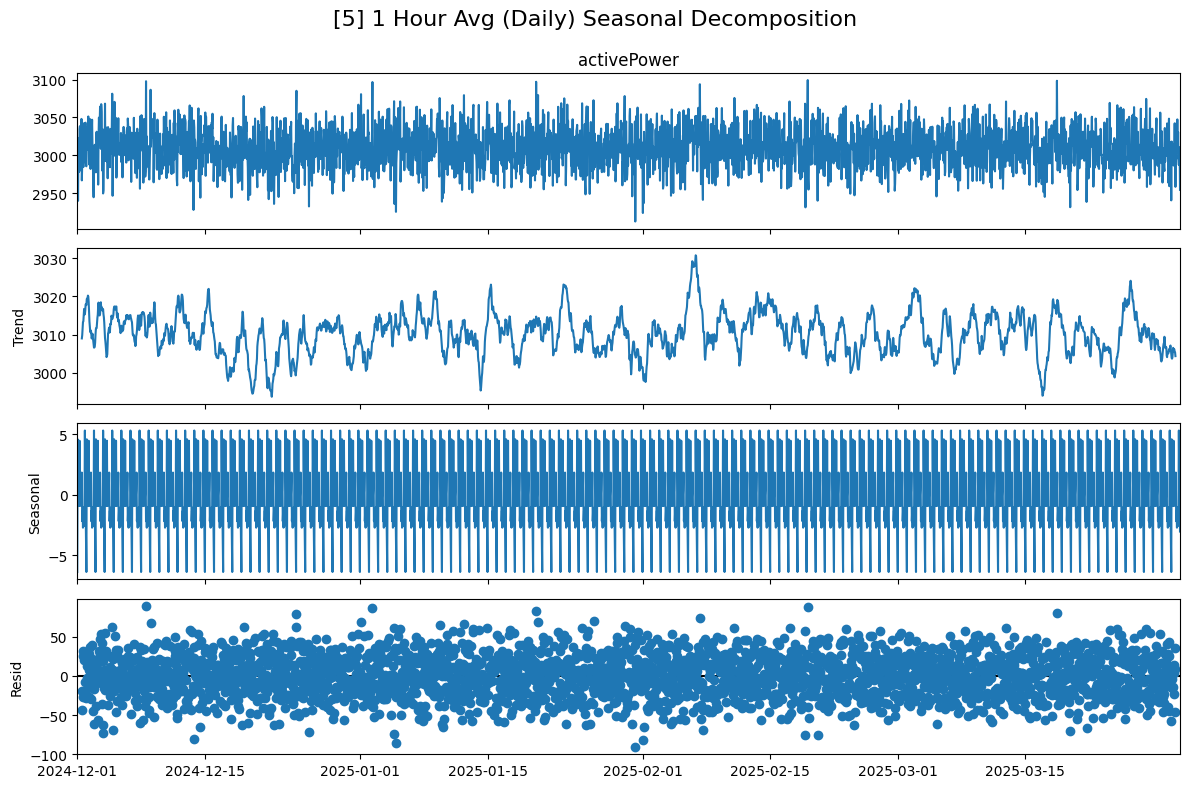


📊 Decomposing 1 Day Avg (Weekly) for module: activePower


/tmp/ipykernel_35/2232643761.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


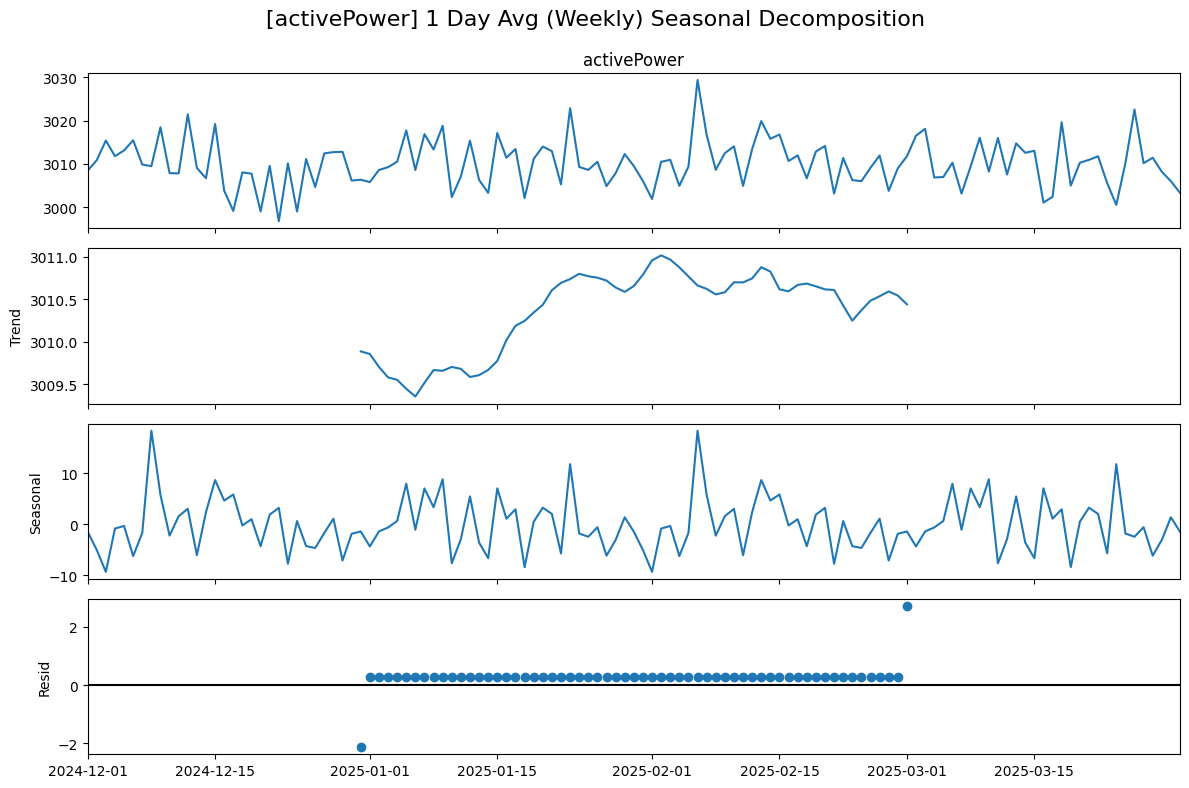

ADF Statistic: -18.9708
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8626
Critical Value (10%): -2.5673
=> The series is stationary at the 0.05 significance level.
ADF Statistic: -54.8692
p-value: 0.0000
Critical Value (1%): -3.4326
Critical Value (5%): -2.8625
Critical Value (10%): -2.5673
=> The series is stationary at the 0.05 significance level.


In [28]:
seasonality_dict = {}

for module, df_mod in df.groupby(level=0):
        df_mod = df_mod.reset_index()           # 모듈 레벨 제거
        df_mod.index = pd.to_datetime(df_mod.datetime)
        # 1시간 주기 (5초 간격 → 720개가 1시간)
        result_1h = downsample_and_decompose(df_mod.copy(), module, 'activePower', 
                           resample_rule='1H', period=24, freq_label='1 Hour Avg (Daily)')
        
        # 1일 주기 (5초 간격 → 17280개가 1일)
        result_1d = downsample_and_decompose(df_mod.copy(), 'activePower',
                           resample_rule='1D', period=30*2, freq_label='1 Day Avg (Weekly)')
    
        # 1개월은 너무 크고 불규칙할 수 있어 resample 후 사용 추천 (예: 1시간 단위로 다운샘플링 후 1달 주기)
        print(result_1h)
        check_stationarity(result_1h.resid)
        
        # 3) 원본에서 계절성만 제거한 시계열 정상성 검사 (추세+잔차 부분)
        seasonality_removed = result_1h.observed - result_1h.seasonal
        check_stationarity(seasonality_removed)

        seasonality_dict[module] = seasonality_removed

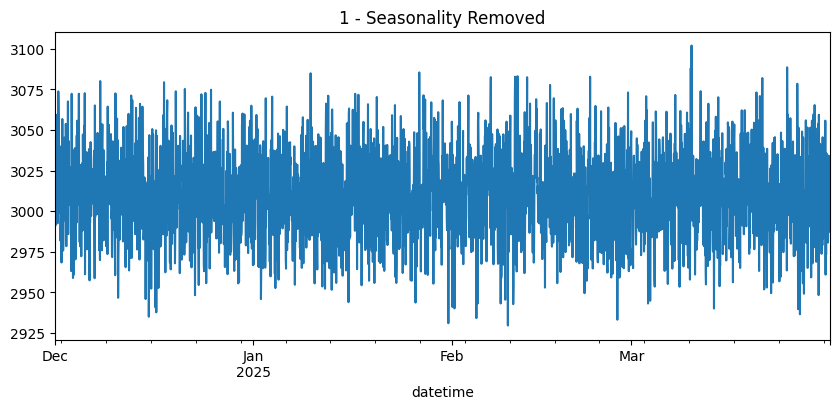


🔧 1 ARIMA Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2904
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -13643.569
Date:                Mon, 26 May 2025   AIC                          27293.137
Time:                        02:09:59   BIC                          27311.058
Sample:                    12-01-2024   HQIC                         27299.594
                         - 03-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0167      0.019      0.892      0.372      -0.020       0.053
ma.L1         -0.9998      0.008   -124.609      0.000      -1.016      -0.984
sigma2       705.7580     20.105

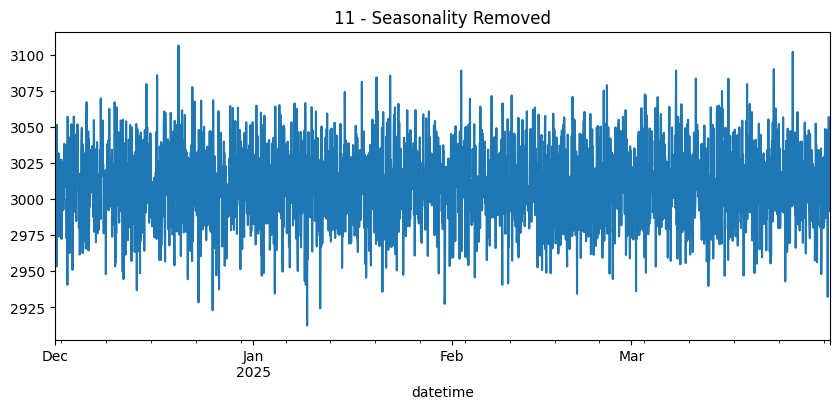


🔧 11 ARIMA Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2904
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -13648.401
Date:                Mon, 26 May 2025   AIC                          27302.802
Time:                        02:10:00   BIC                          27320.722
Sample:                    12-01-2024   HQIC                         27309.259
                         - 03-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0055      0.018      0.306      0.759      -0.030       0.041
ma.L1         -0.9997      0.003   -339.037      0.000      -1.005      -0.994
sigma2       708.0328     18.84

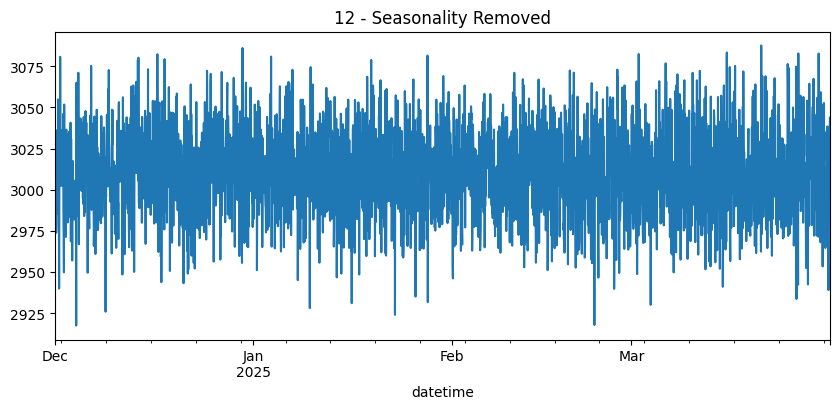


🔧 12 ARIMA Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2904
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -13643.554
Date:                Mon, 26 May 2025   AIC                          27293.108
Time:                        02:10:01   BIC                          27311.029
Sample:                    12-01-2024   HQIC                         27299.565
                         - 03-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0019      0.019     -0.101      0.919      -0.039       0.035
ma.L1         -0.9995      0.002   -538.874      0.000      -1.003      -0.996
sigma2       705.8982     19.00

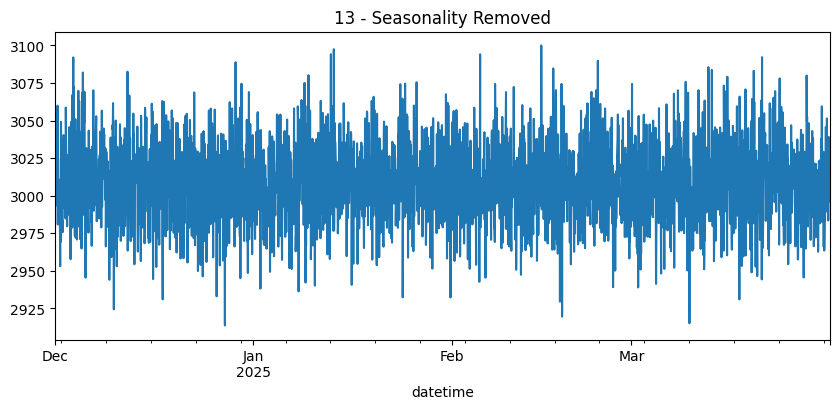


🔧 13 ARIMA Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2904
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -13671.009
Date:                Mon, 26 May 2025   AIC                          27348.017
Time:                        02:10:02   BIC                          27365.938
Sample:                    12-01-2024   HQIC                         27354.474
                         - 03-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0271      0.018      1.469      0.142      -0.009       0.063
ma.L1         -0.9996      0.002   -462.377      0.000      -1.004      -0.995
sigma2       719.3270     18.67

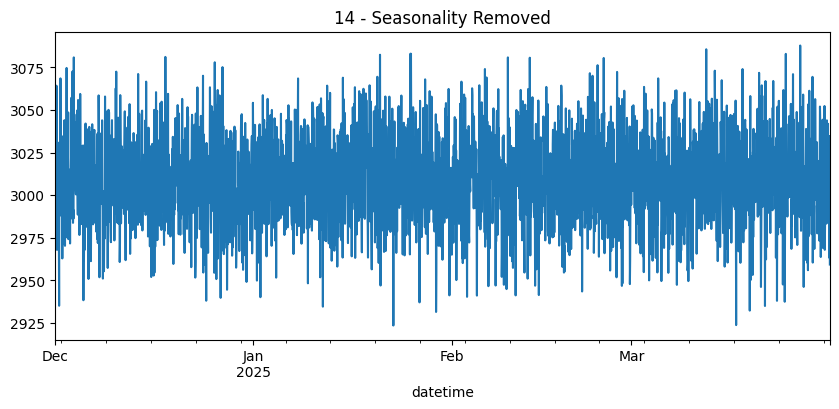


🔧 14 ARIMA Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2904
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -13622.042
Date:                Mon, 26 May 2025   AIC                          27250.083
Time:                        02:10:03   BIC                          27268.004
Sample:                    12-01-2024   HQIC                         27256.540
                         - 03-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0185      0.019      0.957      0.338      -0.019       0.056
ma.L1         -0.9996      0.002   -453.366      0.000      -1.004      -0.995
sigma2       695.4856     19.05

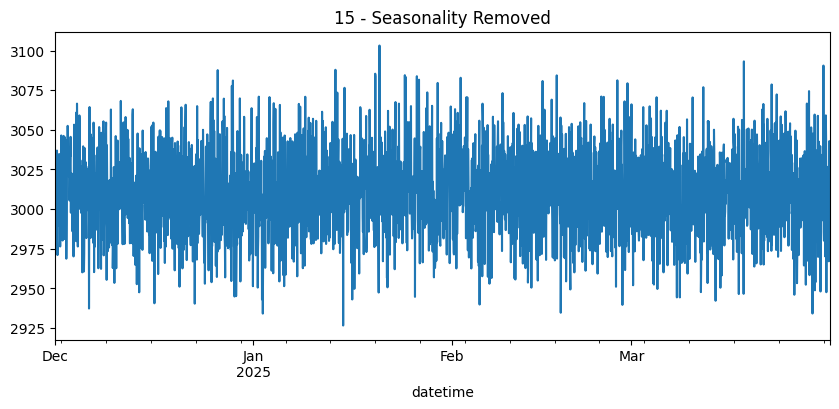


🔧 15 ARIMA Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2904
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -13622.800
Date:                Mon, 26 May 2025   AIC                          27251.600
Time:                        02:10:04   BIC                          27269.521
Sample:                    12-01-2024   HQIC                         27258.057
                         - 03-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0082      0.019     -0.444      0.657      -0.045       0.028
ma.L1         -0.9976      0.001   -668.394      0.000      -1.001      -0.995
sigma2       696.1682     18.85

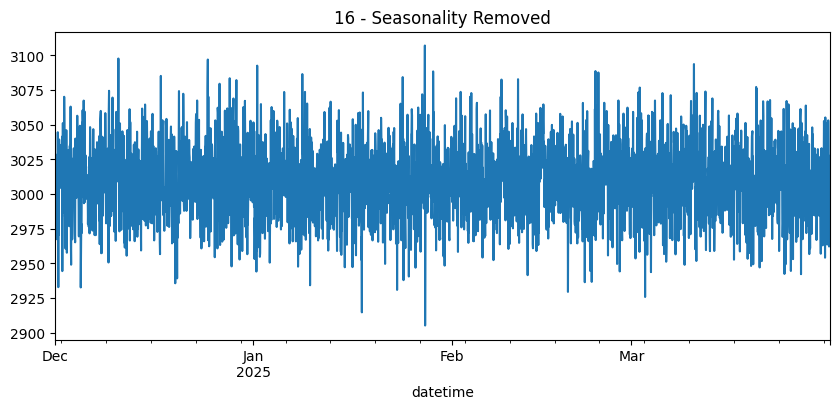


🔧 16 ARIMA Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2904
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -13712.061
Date:                Mon, 26 May 2025   AIC                          27430.122
Time:                        02:10:05   BIC                          27448.043
Sample:                    12-01-2024   HQIC                         27436.579
                         - 03-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0350      0.018      1.975      0.048       0.000       0.070
ma.L1         -1.0000      0.071    -14.130      0.000      -1.139      -0.861
sigma2       739.5516     55.40

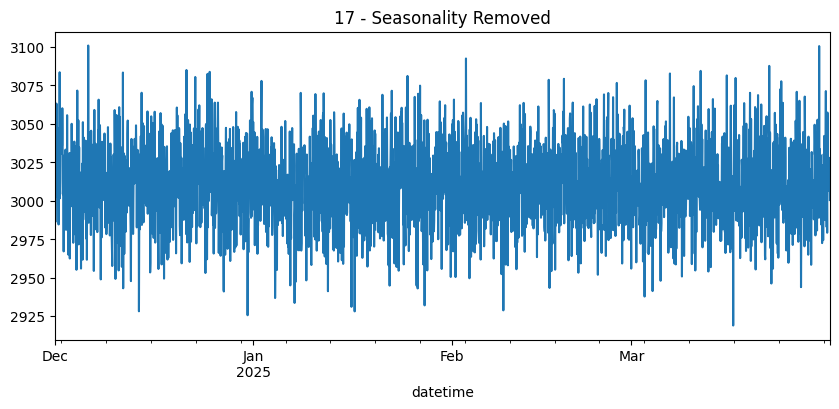


🔧 17 ARIMA Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2904
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -13582.096
Date:                Mon, 26 May 2025   AIC                          27170.192
Time:                        02:10:06   BIC                          27188.113
Sample:                    12-01-2024   HQIC                         27176.649
                         - 03-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0239      0.019      1.253      0.210      -0.013       0.061
ma.L1         -0.9999      0.014    -72.248      0.000      -1.027      -0.973
sigma2       676.4527     19.49

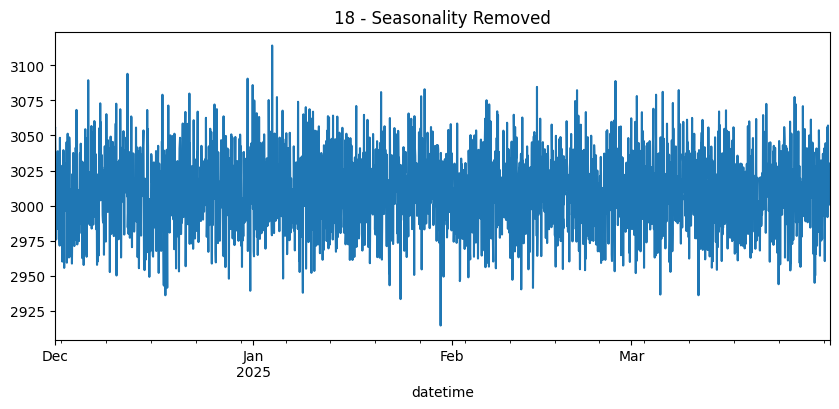


🔧 18 ARIMA Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2904
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -13635.719
Date:                Mon, 26 May 2025   AIC                          27277.437
Time:                        02:10:07   BIC                          27295.358
Sample:                    12-01-2024   HQIC                         27283.894
                         - 03-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0039      0.019     -0.206      0.837      -0.041       0.033
ma.L1         -0.9998      0.005   -208.558      0.000      -1.009      -0.990
sigma2       701.7830     19.27

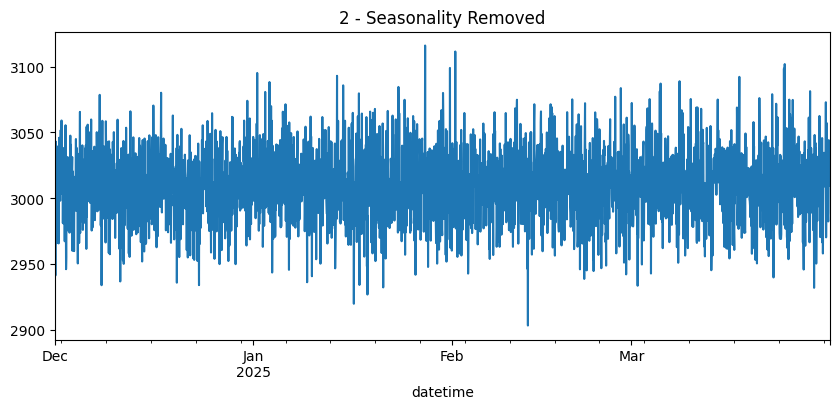


🔧 2 ARIMA Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2904
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -13682.405
Date:                Mon, 26 May 2025   AIC                          27370.810
Time:                        02:10:08   BIC                          27388.731
Sample:                    12-01-2024   HQIC                         27377.267
                         - 03-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0170      0.019      0.885      0.376      -0.021       0.055
ma.L1         -0.9997      0.005   -205.747      0.000      -1.009      -0.990
sigma2       724.8827     18.263

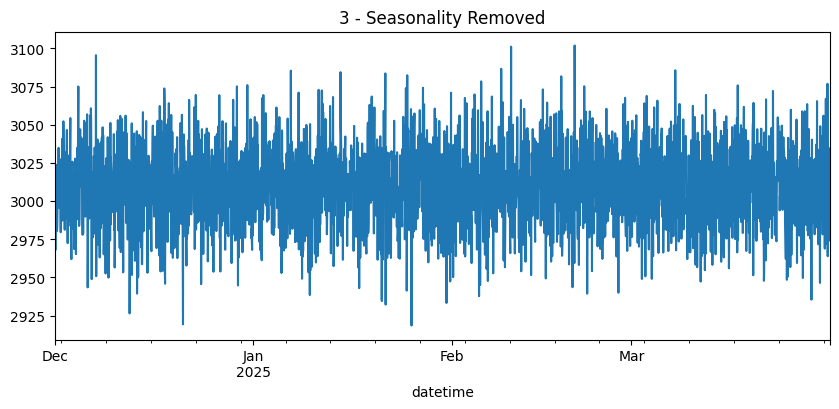


🔧 3 ARIMA Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2904
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -13639.489
Date:                Mon, 26 May 2025   AIC                          27284.979
Time:                        02:10:09   BIC                          27302.899
Sample:                    12-01-2024   HQIC                         27291.436
                         - 03-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0186      0.018     -1.040      0.298      -0.054       0.016
ma.L1         -0.9996      0.003   -348.537      0.000      -1.005      -0.994
sigma2       703.8094     19.218

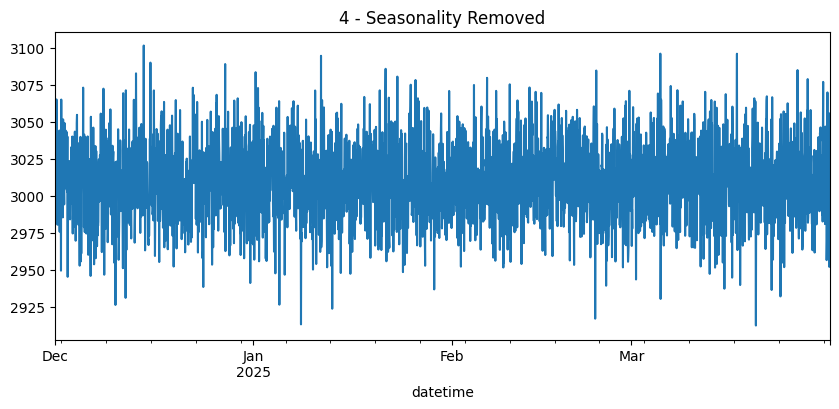


🔧 4 ARIMA Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2904
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -13634.586
Date:                Mon, 26 May 2025   AIC                          27275.173
Time:                        02:10:10   BIC                          27293.093
Sample:                    12-01-2024   HQIC                         27281.630
                         - 03-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0137      0.018     -0.741      0.459      -0.050       0.022
ma.L1         -0.9988      0.001   -794.645      0.000      -1.001      -0.996
sigma2       701.7469     18.236

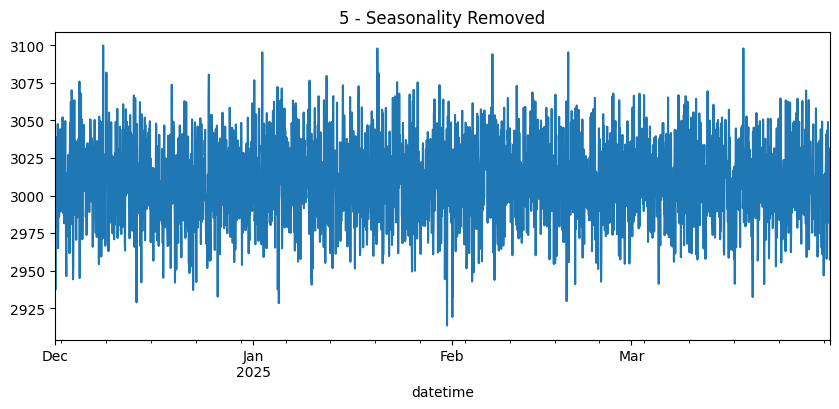


🔧 5 ARIMA Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2904
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -13673.394
Date:                Mon, 26 May 2025   AIC                          27352.788
Time:                        02:10:11   BIC                          27370.709
Sample:                    12-01-2024   HQIC                         27359.245
                         - 03-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0184      0.019     -0.991      0.322      -0.055       0.018
ma.L1         -1.0000      0.033    -30.271      0.000      -1.065      -0.935
sigma2       720.1226     30.625

In [30]:
from statsmodels.tsa.arima.model import ARIMA

for module, ts in seasonality_dict.items():
    try:
        seasonality_dict[module].plot(figsize=(10, 4), title=f'{module} - Seasonality Removed')
        plt.show()

        model = ARIMA(ts.dropna(), order=(1, 1, 1))
        model_fit = model.fit()
        print(f"\n🔧 {module} ARIMA Summary:")
        print(model_fit.summary())
    except Exception as e:
        print(f"❌ Failed for {module}: {e}")

In [ ]:
df.head()

In [27]:
gc.collect()

52438

In [ ]:
df = pd.DataFrame()

In [ ]:
# try:
#     # 각 DataFrame에 module 컬럼이 이미 존재한다면 그냥 concat만 하면 됩니다.
#     df = pd.concat(module_data.values(), ignore_index=False)
    
# except Exception as e:
#     print(e)

In [ ]:
# df.reset_index()

In [ ]:
# df.reset_index().set_index(['module', 'datetime'], inplace=True)
# df.head()

In [30]:
# # Feature Engineering
df['avg_voltage'] = (df['voltageR'] + df['voltageS'] + df['voltageT']) / 3
df['avg_current'] = (df['currentR'] + df['currentS'] + df['currentT']) / 3
df['avg_power_factor'] = (df['powerFactorR'] + df['powerFactorS'] + df['powerFactorT']) / 3
df['avg_line_voltage'] = (df['voltageRS'] + df['voltageST'] + df['voltageTR']) / 3


V_list = ['voltageR', 'voltageS', 'voltageT']
df['voltage_imbalance'] = (df[V_list].max(axis=1) - df[V_list].min(axis=1)) / df[V_list].mean(axis=1) * 100

df['V_I_ratio_R'] = df['voltageR'] / df['currentR']
df['V_I_ratio_S'] = df['voltageS'] / df['currentS']
df['V_I_ratio_T'] = df['voltageT'] / df['currentT']

df['low_efficiency'] = (df['avg_power_factor'] < 90).astype(int)  # 90% 미만이면 1 (비효율)

# # 계산된 유효 전력 (단위: kW)
df['calc_active_power'] = np.sqrt(3) * df['avg_line_voltage'] * df['avg_current'] * df['avg_power_factor'] / 1000

# df.drop(columns=['voltageR', 'voltageS', 'voltageT'])

In [31]:
gc.collect()

50

In [ ]:
df.head()

In [18]:
# !git remote add origin https://github.com/ejsong25/AIStudy.git
# !git add .
!git commit -m "check seasonality"

On branch master

Initial commit

nothing to commit (create/copy files and use "git add" to track)


In [ ]:
# Feature Engineering
try:
    df_corr=df.corr(numeric_only=True)
    active_corr = df_corr['activePower'].sort_values(ascending=False)
    print(active_corr.iloc[1:])  # 첫 번째 인덱스(자기 자신)를 제외한 상관관게 내림차순 정렬
    important_features = active_corr[active_corr >= 0.01].index
    print(important_features)
except Exception as e:
    print(f"Error occurred: {e}")

In [2]:
df.head()

NameError: name 'df' is not defined

In [ ]:
important_features

In [ ]:
gc.collect()

In [ ]:
df_wide = df[important_features].unstack('module')
df_wide.head()

In [ ]:
df_wide.columns = [f"{col[1]}_{col[0]}" for col in df_wide.columns]
df_wide.head()

In [ ]:
df_wide.isna().sum()[df_wide.isna().sum() > 0]

In [ ]:
# 1. '_activePower' 포함 컬럼만 선택
active_power_df = df_wide.filter(like='activePower')

# 2. total_activePower 컬럼 생성
df_wide['total_activePower'] = active_power_df.sum(axis=1)

# 3. 해당 컬럼들 제거
df_wide = df_wide.drop(columns=active_power_df.columns)

In [ ]:
gc.collect()

In [ ]:
df_wide['hour'] = df_wide.index.hour
df_wide['day'] = df_wide.index.day
df_wide['weekday'] = df_wide.index.weekday
df_wide['is_night'] = df_wide['hour'].apply(lambda x: 1 if x < 6 or x > 20 else 0)
df_wide['is_weekend'] = (df_wide['weekday'] >= 5).astype(int)

In [ ]:
df_wide_corr=df_wide.corr(numeric_only=True)
df_wide_corr_active_corr = df_wide_corr['total_activePower'].sort_values(ascending=False)
print(df_wide_corr_active_corr.iloc[1:])  # 첫 번째 인덱스(자기 자신)를 제외한 상관관게 내림차순 정렬
final_important_features = df_wide_corr_active_corr[df_wide_corr_active_corr >= 0.01].index
print(final_important_features)

In [1]:
top_10_features = final_important_features[1:12]
top_10_features

NameError: name 'final_important_features' is not defined

In [ ]:
df_reduced = df_wide[top_10_features].copy()

print(f"Data size reduction:")
print(f"   Original: {df_wide.shape}")
print(f"   Reduced:  {df_reduced.shape}")
print(f"   Features: {len(df_wide.columns)} -> {len(df_reduced.columns)}")
print(f"   Reduction: {(1 - len(df_reduced.columns)/len(df_wide.columns))*100:.1f}%")

In [ ]:
# # 정상성 검정 - ADF
# from statsmodels.tsa.stattools import adfuller

# for col in df_reduced.columns:
#     result = adfuller(df_reduced[col])
#     print(f"{col}: p-value = {result}")

In [ ]:
# # 정상성 확인

# from statsmodels.tsa.stattools import adfuller

# data_ = df_reduced['total_activePower']

# print('ADF test with total active Power')
# ADF_result = adfuller(data_)

# # ADF 통계량
# print('ADF status : %f' %ADF_result[0])

# # p값
# print('p-value: %f' %ADF_result[1])

- Pair Plot
- 이상치가 있는지 확인
어떠한 값들이 있는지 unique() 등으로 확인
값들이 얼만큼 있는지 count() 등으로 확인
값들이 어떻게 분포해 있는지 표준편차 확인
컬럼 별로 통계량(min, max, mean, median, z-sigma, 3-sigma 등)을 확인
추세(Trend), 계절성(Seasonality), 순환성(Cyclicity), 주기성(Periodicity)을 육안으로 1차 확인
같은 컬럼도 여러 형태의 plot으로 확인
다중공선성(Multicollinearity) 확인을 위한 heatmap 시각화

노이즈 : 이동 평균 값으로 대체

# 시각화

# 모델링

In [ ]:
from tqdm import tqdm
import time
import numpy as np

def split_sequences(data, window_size, target_col, feature_cols):
   print("Creating sliding windows...")
   start_time = time.time()
   
   feature_data = data[feature_cols].values
   target_data = data[target_col].values
   
   total_samples = len(data) - window_size
   num_features = len(feature_cols)
   
   print(f"Total samples: {total_samples:,}")
   print(f"Window size: {window_size}, Features: {num_features}")
   
   X = np.zeros((total_samples, window_size, num_features))
   y = np.zeros(total_samples)
   
   for i in tqdm(range(total_samples), desc="Creating windows"):
       X[i] = feature_data[i:i+window_size]
       y[i] = target_data[i+window_size]
   
   end_time = time.time()
   print(f"Windowing completed! Time: {end_time - start_time:.2f}s")
   
   return X, y

window_size = 24

X, y = split_sequences(df_reduced, window_size, top_10_features[0], top_10_features[1:])

In [ ]:
print(f"Windowing results:")
print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape}")
print(f"   Memory usage: {X.nbytes / 1024**2:.1f} MB")

In [ ]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_2d = X_train.reshape(-1, X_train.shape[-1])
X_test_2d = X_test.reshape(-1, X_test.shape[-1])

X_train_2d_scaled = scaler_X.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_X.transform(X_test_2d)

In [ ]:
X_train_scaled = X_train_2d_scaled.reshape(X_train.shape)
X_test_scaled = X_test_2d_scaled.reshape(X_test.shape)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

print("Scaling completed!")

In [ ]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Split results:")
print(f"   Train: X={X_train.shape}, y={y_train.shape}")
print(f"   Test:  X={X_test.shape}, y={y_test.shape}")
print(f"   Train flat: {X_train_flat.shape}")
print(f"   Test flat: {X_test_flat.shape}")

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("Training XGBoost with GPU...")
xgb_model = xgb.XGBRegressor(
   n_estimators=1000,
   max_depth=6,
   learning_rate=0.1,
   tree_method='gpu_hist',
   gpu_id=0,
   random_state=42,
   n_jobs=-1
)

xgb_model.fit(X_train_flat, y_train)
xgb_pred = xgb_model.predict(X_test_flat)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print(f"XGBoost - MAE: {xgb_mae:.4f}, RMSE: {xgb_rmse:.4f}")

In [ ]:
print(f"XGBoost                  - MAE: {xgb_mae:.4f}, RMSE: {xgb_rmse:.4f}")

# 성능 평가

# 결과 취합

In [ ]:
wide_df = df.pivot(columns='module', values='activePower')
wide_df.tail(3)

In [ ]:
sample_submission_df = pd.read_csv(dirname + '/submissionfile_sample.csv')
sample_submission_df.head()

In [ ]:
# 총 합 - 3600row 마다의 합
sample_submission_df['hourly_pow'] = wide_df.apply()
sample_submission_df['agg_pow'] = sample_submission_df['hourly_pow'].sum()
sample_submission_df['may_bill'] = sample_submission_df['agg_pow'] * 180
sample_submission_df['may_carbon'] = sample_submission_df['agg_pow'] * 0.424

In [ ]:
# submission = sample_submission_df.to_csv()